Abrego Islas Iván

Ciencia de Datos - Laboratorio 02

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display

Para este laboratorio elegi trabajar con el dataset de 10k pacientes de COVID-19:
Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. Synthea™ Novel coronavirus (COVID-19) model and synthetic data set. Intelligence-Based Medicine. 2020 Nov;1:100007. https://doi.org/10.1016/j.ibmed.2020.100007

# Carga con dtypes explicitos:

In [4]:
# cargar datos crudos, permitir que pandas infiera dtypes
enc = pd.read_csv('encounters.csv')
pat = pd.read_csv('patients.csv')
obs = pd.read_csv('observations.csv')

**Checar la memoria usada por cada dataframe:**

In [5]:
enc.memory_usage(deep=True).sum() / 1e6

np.float64(252.112421)

In [6]:
pat.memory_usage(deep=True).sum() / 1e6

np.float64(14.372668)

In [7]:
obs.memory_usage(deep=True).sum() / 1e6

np.float64(885.666874)

**Checar columnas de pacientes:**

**Puedo ver que la gran mayoria de las columnas tienen dtype object**

In [8]:
pat.dtypes

Id                      object
BIRTHDATE               object
DEATHDATE               object
SSN                     object
DRIVERS                 object
PASSPORT                object
PREFIX                  object
FIRST                   object
LAST                    object
SUFFIX                  object
MAIDEN                  object
MARITAL                 object
RACE                    object
ETHNICITY               object
GENDER                  object
BIRTHPLACE              object
ADDRESS                 object
CITY                    object
STATE                   object
COUNTY                  object
ZIP                    float64
LAT                    float64
LON                    float64
HEALTHCARE_EXPENSES    float64
HEALTHCARE_COVERAGE    float64
dtype: object

Revisando el diccionario (https://github.com/synthetichealth/synthea/wiki/CSV-File-Data-Dictionary#patients) me puedo dar cuenta de a qué corresponde cada columna:

Fechas: BIRTHDATE, DEATHDATE.

Identificadores: Id, SSN, DRIVERS, PASSPORT, PREFIX, FIRST, LAST, SUFFIX, MAIDEN, ADDRESS, LAT, LON, HEALTHCARE_EXPENSES, HEALTHCARE_COVERAGE.

Categoricas: MARITAL, RACE, ETHNICITY, BIRTHPLACE, CITY, STATE, COUNTY, ZIP.

Tambien quiero dar un vistazo rapido del dataset:

In [9]:
pat.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,NaN,999-68-6630,NaN,NaN,NaN,Jacinto644,Kris249,NaN,...,Beverly Massachusetts US,888 Hickle Ferry Suite 38,Springfield,Massachusetts,Hampden County,1106.0,42.151961,-72.598959,8446.49,1499.08
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,NaN,999-15-5895,NaN,NaN,NaN,Alva958,Krajcik437,NaN,...,Boston Massachusetts US,1048 Skiles Trailer,Walpole,Massachusetts,Norfolk County,2081.0,42.177370,-71.281353,89893.40,1845.72
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,NaN,999-27-3385,S99971451,X53218815X,Mr.,Jayson808,Fadel536,NaN,...,Springfield Massachusetts US,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,577445.86,3528.84
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,NaN,999-73-2461,S99956432,NaN,NaN,Jimmie93,Harris789,NaN,...,Worcester Massachusetts US,201 Mitchell Lodge Unit 67,Pembroke,Massachusetts,Plymouth County,NaN,42.075292,-70.757035,336701.72,2705.64
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,NaN,999-60-7372,S99917327,X58903159X,Mr.,Gregorio366,Auer97,NaN,...,Patras Achaea GR,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,484076.34,3043.04


In [10]:
len(pat) # numero de pacientes

12352

**A partir de esto puedo tomar decisiones sobre los dtypes:**

In [11]:
pat2 = pd.read_csv(
    'patients.csv',
dtype={'Id':'string',
      'SSN': 'string',     
      'DRIVERS': 'string',
      'PASSPORT': 'string',
      'PREFIX': 'string',
      'FIRST': 'string',
      'LAST': 'string',
      'SUFFIX': 'string',
      'MAIDEN': 'string', 
      'MARITAL': 'category',
      'RACE': 'category',
      'ETHNICITY': 'category',
      'GENDER': 'category',
      'BIRTHPLACE': 'string',
      'ADDRESS': 'string',
      'CITY': 'string',
      'STATE': 'string',
      'COUNTY': 'string',
      'ZIP': 'float32',
      'LAT': 'float32',
      'LON': 'float32',
      'HEALTHCARE_EXPENSES': 'float32',
      'HEALTHCARE_COVERAGE': 'float32'},
parse_dates=['BIRTHDATE', 'DEATHDATE'])

**Nota**

Aqui me encuentro con algunos problemas. Hay algunas columnas que yo quisiera convertir a enteros, pero para lograrlo tendre que manipular un poco mas a fondo los datos. 

En especifico:

SSN puede ser entero, pero debo quitar los guiones.
DRIVERS y PASSPORT tambien podrian ser enteros si le quitara las letras, pero por estos no me preocupo porque de todas formas planeo eliminar esas columnas. 
ZIP también puede ser entero, pero primero debo deshacerme de los NaNs. 

Por ahora dejare estas columnas como floats, pero en la siguiente seccion resolvere estos problemas.

A continuacion repito un proceso similar para los otros dos archivos:


In [12]:
# visualizar datset
enc.head() 

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16T01:02:32Z,2019-02-16T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02T01:02:32Z,2019-08-02T01:32:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN
2,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31T01:02:32Z,2019-10-31T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media
3,821e57ac-9304-46a9-9f9b-83daf60e9e43,2020-01-31T01:02:32Z,2020-01-31T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN
4,681c380b-3c84-4c55-80a6-db3d9ea12fee,2020-03-02T01:02:32Z,2020-03-02T01:58:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,fd328395-ab1d-35c6-a2d0-d05a9a79cf11,9c875a09-93e0-39aa-9260-ad264bbdd3fe,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,185345009,Encounter for symptom (procedure),129.16,129.16,69.16,NaN,NaN


Siguiendo algunos consejos de Matt Harrisonn (https://www.youtube.com/watch?v=zgbUk90aQ6A)

Aqui uso los metodos .describe() y .value_counts() para revisar si hay valores faltantes y tomar decisiones sobre los dtypes:

In [13]:
len(enc)

321528

In [14]:
enc.ENCOUNTERCLASS.describe()

count       321528
unique           6
top       wellness
freq        156219
Name: ENCOUNTERCLASS, dtype: object

In [15]:
enc.DESCRIPTION.describe()

count                                         321528
unique                                            56
top       General examination of patient (procedure)
freq                                          141988
Name: DESCRIPTION, dtype: object

In [16]:
enc.ENCOUNTERCLASS.value_counts(dropna=False)

ENCOUNTERCLASS
wellness      156219
ambulatory     86069
outpatient     58367
inpatient       9584
emergency       7233
urgentcare      4056
Name: count, dtype: int64

In [17]:
enc.dtypes

Id                      object
START                   object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PROVIDER                object
PAYER                   object
ENCOUNTERCLASS          object
CODE                     int64
DESCRIPTION             object
BASE_ENCOUNTER_COST    float64
TOTAL_CLAIM_COST       float64
PAYER_COVERAGE         float64
REASONCODE             float64
REASONDESCRIPTION       object
dtype: object

In [18]:
enc2 = pd.read_csv(
    'encounters.csv',
    dtype={'Id': 'string',
          'PATIENT': 'string',
          'ORGANIZATION': 'string',
          'PROVIDER': 'string',
          'PAYER': 'string',
          'ENCOUNTERCLASS': 'category',  # claramente categorica, unicamente hay 6 posibles clases
          'CODE': 'int32',
          'DESCRIPTION': 'category',     # aqui tengo mis dudas, 56 valores unicos son demasiados para dejarlo como categorica?
          'BASE_ENCOUNTER_COST': 'float32',
          'TOTAL_CLAIM_COST': 'float32',
          'PAYER_COVERAGE': 'float32',
          'REASONCODE': 'float64',
          'REASONDESCRIPTION': 'string'},
    parse_dates=['START', 'STOP']
)

In [19]:
# observations
obs.dtypes

DATE           object
PATIENT        object
ENCOUNTER      object
CODE           object
DESCRIPTION    object
VALUE          object
UNITS          object
TYPE           object
dtype: object

In [20]:
obs.head(10)

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,82.7,cm,numeric
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,2.0,{score},numeric
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,12.6,kg,numeric
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,77606-2,Weight-for-length Per age and sex,86.1,%,numeric
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9843-4,Head Occipital-frontal circumference,46.9,cm,numeric
5,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8462-4,Diastolic Blood Pressure,76.0,mm[Hg],numeric
6,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8480-6,Systolic Blood Pressure,107.0,mm[Hg],numeric
7,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8867-4,Heart rate,68.0,/min,numeric
8,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9279-1,Respiratory rate,13.0,/min,numeric
9,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text


In [21]:
len(obs)

1659750

In [22]:
obs.DESCRIPTION.value_counts()

DESCRIPTION
Diastolic Blood Pressure                                  48132
Systolic Blood Pressure                                   48132
Body Weight                                               46332
Heart rate                                                46332
Respiratory rate                                          46332
                                                          ...  
VR-12 Bodily pain (BP) score - oblique method                 1
VR-12 Role physical (RP) score - oblique method               1
VR-12 Physical functioning (PF) score - oblique method        1
Tumor marker Cancer                                           1
VR-12 Mental health (MH) score - oblique method               1
Name: count, Length: 201, dtype: int64

In [23]:
obs.VALUE.describe()

count                        1659750
unique                          9029
top       Negative (qualifier value)
freq                           46421
Name: VALUE, dtype: object

In [24]:
obs.TYPE.describe()

count     1659750
unique          2
top       numeric
freq      1560281
Name: TYPE, dtype: object

In [25]:
obs.DESCRIPTION.describe()

count                      1659750
unique                         201
top       Diastolic Blood Pressure
freq                         48132
Name: DESCRIPTION, dtype: object

In [26]:
obs2 = pd.read_csv(
    'observations.csv',
    dtype={
        'PATIENT': 'string',
        'ENCOUNTER': 'string',
        'CODE': 'string',
        'DESCRIPTION': 'string',
        'VALUE': 'string',
        'UNITS': 'string',
        'TYPE': 'category'
    },
    parse_dates=['DATE']
)

**Revisar cuanta memoria se salva unicamente cargando los datos con dtypes explicitos:**

In [27]:
def get_memory_usage(df, mb=True):
    #toma un dataframe y devuelve su uso de memoria en mb por default
    mem = df.memory_usage(deep=True).sum()
    if mb:
        mem /= 1e6
    return mem

In [28]:
usage = pd.DataFrame(
    {
        'Archivo': ['Patients', 'Observations', 'Encounters'],
        'Memoria antes': [get_memory_usage(i) for i in (pat, obs, enc)],
        'Memoria despues': [get_memory_usage(i) for i in (pat2, obs2, enc2)]
    }
)

In [29]:
display(Markdown(usage.to_markdown(index=False)))

| Archivo      |   Memoria antes |   Memoria despues |
|:-------------|----------------:|------------------:|
| Patients     |         14.3727 |           11.2759 |
| Observations |        885.667  |          713.077  |
| Encounters   |        252.112  |          169.14   |

**Claramente, la mejor reduccion de memoria estuvo en el archivo encounters, donde se logra una reduccion cercana al 50%. Esto tiene sentido considerando que ese archivo es el que permite tomar mas decisiones de manera sencilla respecto al dtype** 

Por otro lado, en el archivo observations es complicado de manejar por las siguientes razones:
* Las columnas PATIENT, ENCOUNTER, DESCRIPTION, UNITS unicamente pueden ser manejadas como strings. Si bien prefiero strings a objects, tengo entendido que este cambio por si mismo no tendrá un impacto tan significativo en la utlizacion de memoria
* La columna value a primera vista podria ser manejada con dtype float, pero cuenta con valores mixtos: de repente mete un string "Never smoker" como resultado de un test de tabaquismo. Esto obliga a que la columna se maneja con un dtype string, aunque claramente seria mas eficiente manejar float para los numeros. 

En la siguiente seccion intentare reducir el uso de memoria de este archivo

# Reducir la memoria al menos 70%

Decidi empezar de 0 desde el dataset original para intentar hacerlo mediante el metodo de encadenamiento, de acuerdo con los consejos de Matt Harrison

In [30]:
# recordar el uso de memoria original y columnas
x = get_memory_usage(obs)
x

np.float64(885.666874)

In [31]:
# objetivo: 70% de reduccion
(x*30)/100

np.float64(265.7000622)

In [32]:
obs.columns.to_list()

['DATE',
 'PATIENT',
 'ENCOUNTER',
 'CODE',
 'DESCRIPTION',
 'VALUE',
 'UNITS',
 'TYPE']

In [33]:
obs.head(10)

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,82.7,cm,numeric
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,2.0,{score},numeric
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,12.6,kg,numeric
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,77606-2,Weight-for-length Per age and sex,86.1,%,numeric
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9843-4,Head Occipital-frontal circumference,46.9,cm,numeric
5,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8462-4,Diastolic Blood Pressure,76.0,mm[Hg],numeric
6,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8480-6,Systolic Blood Pressure,107.0,mm[Hg],numeric
7,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8867-4,Heart rate,68.0,/min,numeric
8,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9279-1,Respiratory rate,13.0,/min,numeric
9,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text


Mi primera aproximacion es seleccionar columnas de interes:

aunque no hay mucho de donde elegir, al ver el diccionario veo que la columna CODE corresponde a "Observation or Lab code from LOINC", lo cual no considero como indispensable. Por lo tanto eligo retirar esta columna:

In [34]:
obs.columns = obs.columns.str.lower() # antes que nada convierto a minusculas los nombres de columnas porque odio trabajar con mayusculas

In [35]:
(obs
.drop(columns=['code'])
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(794.497996)

Con este primer paso logramos bajar de 885 a 794

Ahora comenzamos a cambiar dtypes, comenzando por la fecha:

In [36]:
(obs
.drop(columns=['code'])
 .assign(date=pd.to_datetime(obs.date))
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(709.850746)

Al cambiar el dtype de date de object a datetime, bajamos de 794 a 709.

Lo siguiente que noto es que la columna description es candidata para ser categorica.

In [37]:
obs.description.value_counts()

description
Diastolic Blood Pressure                                  48132
Systolic Blood Pressure                                   48132
Body Weight                                               46332
Heart rate                                                46332
Respiratory rate                                          46332
                                                          ...  
VR-12 Bodily pain (BP) score - oblique method                 1
VR-12 Role physical (RP) score - oblique method               1
VR-12 Physical functioning (PF) score - oblique method        1
Tumor marker Cancer                                           1
VR-12 Mental health (MH) score - oblique method               1
Name: count, Length: 201, dtype: int64

 Como vimos antes usando el metodo value_counts(), cuenta con 201 variables unicas. De entrada me parecio demasiado, pero tambien note que la variable que mas se repite, "diastolic blood pressure", se repite 48k veces. Por esa razon me parecio buena idea dejarla como categorica. 
 
Por otro lado, noto que las columnas patient y encounter tienen valores repetidos, indicando que el mismo paciente cuenta con varias observaciones. Por ahora dejare esas columnas con dtype string, pero si me hace falta memoria, puedo volver a ellas y pensar en alguna manera de agruparlas.

In [38]:
(obs
.drop(columns=['code'])
.assign(date=pd.to_datetime(obs.date)
       )
.astype({'patient': 'string',
         'encounter': 'string',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(566.586273)

Hasta ahora este cambio ha sido el mas importante, logramos bajar de 709 a 566. Ahi vamos ahi vamos

En este punto pense en agregar en la celda anterior, dentro del metodo .astype, a la columna type, la cual solo tiene dos posibles valores y claramente puede ser tratada como categorica. Sin embargo, noto que esta directamente relacionada tanto con la columna value como con la columna unit y decido que puede ser inferida a partir de ellas. Por esta razon considero innecesario seguir teniendo cargada esta columna y decido eliminarla.

In [39]:
(obs
.drop(columns=['code', 'type'])
.assign(date=pd.to_datetime(obs.date)
       )
.astype({'patient': 'string',
         'encounter': 'string',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(473.93868)

Con este cambio bajamos de 566 a 473

Lo siguiente que quiero hacer es convertir la columna units a category, pero noto que cuenta con NaNs, asi que buscare la manera de deshacerme de ellos:

In [40]:
obs.units.describe()

count     1576343
unique         44
top             %
freq       227352
Name: units, dtype: object

lo primero es verificar que efectivamente sea canidadata para category. Al contar con 44 valores unicos considero que si lo es.

Ahora a ver que pasa con esos nans, usare el metodo query para empezar a explorar

In [41]:
obs.query('units.isna()')

,date,patient,encounter,code,description,value,units,type
9,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text
21,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,821e57ac-9304-46a9-9f9b-83daf60e9e43,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text
29,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,92142-9,Influenza virus A RNA [Presence] in Respirator...,Negative (qualifier value),NaN,text
30,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,92141-1,Influenza virus B RNA [Presence] in Respirator...,Negative (qualifier value),NaN,text
31,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,92131-2,Respiratory syncytial virus RNA [Presence] in ...,Negative (qualifier value),NaN,text
...,...,...,...,...,...,...,...,...
1659519,2020-03-04,2712205f-755e-4897-acb3-926895b7d635,a18d0f16-bc12-4897-8844-8c3ebc2464fc,94040-3,Adenovirus A+B+C+D+E DNA [Presence] in Respira...,Negative (qualifier value),NaN,text
1659520,2020-03-04,2712205f-755e-4897-acb3-926895b7d635,a18d0f16-bc12-4897-8844-8c3ebc2464fc,94531-1,SARS-CoV-2 RNA Pnl Resp NAA+probe,Detected (qualifier value),NaN,text
1659549,2020-03-17,2712205f-755e-4897-acb3-926895b7d635,87e55b1f-8812-4783-a94f-1efff5461ce4,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text
1659620,2020-04-07,2712205f-755e-4897-acb3-926895b7d635,4029aa0b-3200-47e6-a063-fb7f13cde2bc,72166-2,Tobacco smoking status NHIS,Never smoker,NaN,text


Lo que puedo notar es que una entrada con NaN en la columna units refiere a un resultado que no puede ser capturado mediante un numero. Por ejemplo podemos ver "negativo" o "positivo" como resultado de algun tipo prueba de influenza, o "never smoker" en lo que probablemente sea un tipo de cuestionario sobre tabaquismo. Al no hacer referencia a un valor numerico, no es necesario capturar sus unidades. Por lo tanto, decido cambiar estos nans por un valor arbitrario que no afecte la calidad del dataset. Decido cambiarlo por "other" y de esta manera puedo tratar la columna completa con datatype category y sin NaNs. Esto lo agregare dentro usando los metodos .assign(), .fillna() y de paso .astype() en mi cadena:

In [42]:
(obs
.drop(columns=['code', 'type'])
.assign(date=pd.to_datetime(obs.date),
        units=obs.units.fillna('other').astype('category')
       )
.astype({'patient': 'string',
         'encounter': 'string',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(388.958014)

Con esto bajamos de 473 a 388. Cada vez nos acercamos mas a nuestro objetivo de 265

Ahora tratemos de resolver el tema con la columna value, la cual tiene tantos valores numericos como strings. De entrada puedo verificar si tiene nans, y utilizar la categoria "other" que asigne en el paso anterior para explorar:

In [43]:
obs.query('value.isna()') # primero verifico si tiene nans, en este caso no tiene

,date,patient,encounter,code,description,value,units,type


In [44]:
# para esta parte decidi trabajar con una variable intermedia 
obs_x = (obs
.drop(columns=['code', 'type'])
.assign(date=pd.to_datetime(obs.date),
        units=obs.units.fillna('other').astype('category')
       )
.astype({'patient': 'string',
         'encounter': 'string',
         'description': 'category'
        }))

In [45]:
obs_x[obs_x['units'] == 'other'].loc[:, ['description', 'value']].describe()

,description,value
count,83407,83407
unique,27,51
top,Tobacco smoking status NHIS,Negative (qualifier value)
freq,14649,46421


Aqui puedo ver que cuenta la variable value cuenta con 51 valores unicos que son texto. Quisiera verlos

In [46]:
obs_x[obs_x['units'] == 'other'].loc[:, 'value'].unique()
# esto me permite hacerme una idea

array(['Never smoker', 'Negative (qualifier value)',
       'Detected (qualifier value)', 'Not detected (qualifier value)',
       'Stroke', 'Positive (qualifier value)', 'Former smoker',
       'COVID-19', 'Worsening (qualifier value)',
       'Malignant neoplasm of breast (disorder)',
       'Improving (qualifier value)', 'Myocardial Infarction',
       'Small cell carcinoma of lung (disorder)',
       "Alzheimer's disease (disorder)", 'Pneumonia',
       'Chronic obstructive bronchitis (disorder)',
       'Non-small cell lung cancer (disorder)', 'Sudden Cardiac Death',
       'Burn injury(morphologic abnormality)', 'Current every day smoker',
       'Treatment changed (situation)', 'Pulmonary emphysema (disorder)',
       'Neoplasm of prostate', 'Bullet wound', 'Cardiac Arrest',
       'Overlapping malignant neoplasm of colon', 'Drug overdose',
       "Familial Alzheimer's disease of early onset (disorder)",
       'None (qualifier value)', 'M0 category (finding)',
       'T2 catego

Viendo esto decido que al ser 51 valores unicos, seria posible almacenarlos con dtype category.

Para esto seria necesario separar la columna value en dos columnas: una que contenga valores numericos y otra que contenga valores no numericos a la cual le puedo asignar dtype category. La estrategia incluiria reemplazar, dentro de la columna numerica, a los entrys donde anteriormente había una valor no numerico con un NaN. A su vez, en la columna no numerica, los entrys donde habría un numero pueden ser llenados con None. Esto permitira tener dos columnas con dtypes float32 y category, en vez de una sola con dtype object. 

Me pregunto si esta operacion, a pesar de agregar una nueva columna, permite ahorrar memoria. Volviendo a mi cadena:

In [47]:
del obs_x

In [48]:
(obs
.assign(date = pd.to_datetime(obs.date),
        units = obs.units.fillna('other').astype('category'),
        num_val = pd.to_numeric(obs['value'], errors='coerce').astype('float32'),
        non_num_val = lambda df: df['value'].where(df['units'] == 'other', None).astype('category')
       )
.drop(columns = ['code', 'type', 'value'])
.astype({'patient': 'string',
         'encounter': 'string',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(307.487948)

A primera vista la estrategia funciono. La memoria bajo de 388 a 307. Use la funcion pd.to_numeric con el atributo errors = coerce para forzar los datos no numericos como nan y el resto como floats, permitiendome mantener dtype de float32 en mi nueva columna "num_val". Luego use lambda junto con el metodo where para encontrar las entradas con unidades "other", las cuales yo se que contenian valores no numericos y mantengo su string, mientras que al resto (con unidades distintas de other) le asigno None. Estas entradas fueron asignadas en una nueva columna llamada "non_num_val".
Finalmente me deshice de la columna value que ya no era necesaria. Todo esto nos acerco bastante al objetivo de 265.

Mi siguiente estrategia es reducir el tamaño del string para las columnas patient y encounter, en las cuales veo cadenas muy grandes y repetidas

In [49]:
obs.query('encounter.isna()')

,date,patient,encounter,code,description,value,units,type
39,2019-08-24,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,NaN,QALY,QALY,1.0,a,numeric
40,2019-08-24,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,NaN,DALY,DALY,0.0,a,numeric
41,2019-08-24,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,NaN,QOLS,QOLS,1.0,{score},numeric
84,2019-08-01,067318a4-db8f-447f-8b6e-f2f61e9baaa5,NaN,QALY,QALY,2.0,a,numeric
85,2019-08-01,067318a4-db8f-447f-8b6e-f2f61e9baaa5,NaN,DALY,DALY,0.0,a,numeric
...,...,...,...,...,...,...,...,...
1659745,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QALY,QALY,59.5,a,numeric
1659746,2019-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,DALY,DALY,18.2,a,numeric
1659747,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,DALY,DALY,18.5,a,numeric
1659748,2019-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QOLS,QOLS,0.7,{score},numeric


In [50]:
obs.query('patient.isna()')

,date,patient,encounter,code,description,value,units,type


en estas dos ultimas celdas veo que patients no tiene nans, pero encounter si tiene bastantes.

In [51]:
obs['patient'].unique()

array(['f0f3bc8d-ef38-49ce-a2bd-dfdda982b271',
       '067318a4-db8f-447f-8b6e-f2f61e9baaa5',
       'ae9efba3-ddc4-43f9-a781-f72019388548', ...,
       'cb03d88e-7f08-46a1-be78-70d9fe8262a7',
       '435be43f-cb57-442f-aeb2-51018b030ed0',
       '2712205f-755e-4897-acb3-926895b7d635'],
      shape=(12352,), dtype=object)

In [52]:
len(obs)

1659750

En este punto, considerando el tamaño del dataset (~1.6M de entradas) y el número de pacientes (~12k), considero que el Id del paciente también es una variable candidata para convertir a category. Anteriormente había asignado a la columna "patient" con un dtype string pero aquí decido cambiarlo a category, el cual por lo que entiendo esta mas optimizado que los strings. Veamos qué tanta memoria ahorra ese cambio. 

In [53]:
(obs
.assign(date = pd.to_datetime(obs.date),
        units = obs.units.fillna('other').astype('category'),
        num_val = pd.to_numeric(obs['value'], errors='coerce').astype('float32'),
        non_num_val = lambda df: df['value'].where(df['units'] == 'other', None).astype('category')
       )
.drop(columns = ['code', 'type', 'value'])
.astype({'patient': 'category', # aqui tenia string pero lo cambio a category
         'encounter': 'string',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(171.04285)

Este cambio hizo toda la diferencia, ya alcanzamos el objetivo de ahorro de memoria. Por lo que veo, hacer el cambio de object a string ahorra memoria, pero el cambio de object a category, incluso trabajando con una alta cantidad de categorias, es mucho mas eficiente.
A pesar de que ya alcanzamos el objetivo, me pregunto si hacer un cambio similar en la columna "encounter" resultaría igual de eficiente.

In [54]:
obs['encounter'].value_counts(dropna=False)

encounter
NaN                                     43488
50ebe448-9afc-466d-ae93-351c0130e17e      747
6cf1bebb-594e-4966-a7ce-1227c44876fd      731
bd60f687-034f-4235-a8bd-b85d8e10ad9e      731
abe8e373-e76f-4501-a5b5-e6c81c3d55d7      725
                                        ...  
dfdddb1c-1b2b-4b88-8654-e22bc9699a62        1
88d5b20a-1c58-424c-a0f2-9db2f150f253        1
6c4961ed-804a-4995-b5ca-2ae87a4d5e29        1
3ea0f52b-1879-42ab-b0e7-3dad880cea6d        1
6d44b0c1-035d-4b56-83f3-cf868bae80de        1
Name: count, Length: 40762, dtype: int64

In [55]:
obs['encounter'].describe()

count                                  1616262
unique                                   40761
top       50ebe448-9afc-466d-ae93-351c0130e17e
freq                                       747
Name: encounter, dtype: object

Veo que encounter cuenta con una gran cantidad de NaNs, pero también cuenta con varios valores repetidos. Esto me hace pensar que también se puede beneficiar de tener dtype category en vez de string

In [56]:
(obs
.assign(date = pd.to_datetime(obs.date),
        units = obs.units.fillna('other').astype('category'),
        num_val = pd.to_numeric(obs['value'], errors='coerce').astype('float32'),
        non_num_val = lambda df: df['value'].where(df['units'] == 'other', None).astype('category')
       )
.drop(columns = ['code', 'type', 'value'])
.astype({'patient': 'category', # aqui tenia string pero lo cambio a category
         'encounter': 'category',
         'description': 'category'
        })
 .memory_usage(deep=True)
 .sum()/1e6
)

np.float64(42.385745)

Efectivamente el cambio fue importante, logramos reducir de 171 hasta 42 MB.
Guardare esta variable para seguir trabajando con ella

In [57]:
obs2 = (obs
.assign(date = pd.to_datetime(obs.date),
        units = obs.units.fillna('other').astype('category'),
        num_val = pd.to_numeric(obs['value'], errors='coerce').astype('float32'),
        non_num_val = lambda df: df['value'].where(df['units'] == 'other', None).astype('category')
       )
.drop(columns = ['type', 'value'])
.astype({'patient': 'category', # aqui tenia string pero lo cambio a category
         'encounter': 'category',
         'description': 'category',
         'code': 'category'
        })
)

In [58]:
y = get_memory_usage(obs2)
f'Alcanzamos reducir hasta {y:.3f} MB, llegando a un {(y*100)/x:.3f}% del dataset original ({x:.3f}MB)'

'Alcanzamos reducir hasta 45.720 MB, llegando a un 5.162% del dataset original (885.667MB)'

**Ahora hare un par de operaciones para verificar que todo haya salido bien**

In [59]:
obs2.head(10)

,date,patient,encounter,code,description,units,num_val,non_num_val
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,{score},2.000000,NaN
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,kg,12.600000,NaN
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,77606-2,Weight-for-length Per age and sex,%,86.099998,NaN
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9843-4,Head Occipital-frontal circumference,cm,46.900002,NaN
5,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8462-4,Diastolic Blood Pressure,mm[Hg],76.000000,NaN
6,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8480-6,Systolic Blood Pressure,mm[Hg],107.000000,NaN
7,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8867-4,Heart rate,/min,68.000000,NaN
8,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9279-1,Respiratory rate,/min,13.000000,NaN
9,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72166-2,Tobacco smoking status NHIS,other,NaN,Never smoker


In [60]:
obs2[obs2['patient']=='f0f3bc8d-ef38-49ce-a2bd-dfdda982b271'] #extraer un paciente

,date,patient,encounter,code,description,units,num_val,non_num_val
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,{score},2.000000,NaN
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,kg,12.600000,NaN
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,77606-2,Weight-for-length Per age and sex,%,86.099998,NaN
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9843-4,Head Occipital-frontal circumference,cm,46.900002,NaN
5,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8462-4,Diastolic Blood Pressure,mm[Hg],76.000000,NaN
6,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8480-6,Systolic Blood Pressure,mm[Hg],107.000000,NaN
7,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8867-4,Heart rate,/min,68.000000,NaN
8,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9279-1,Respiratory rate,/min,13.000000,NaN
9,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72166-2,Tobacco smoking status NHIS,other,NaN,Never smoker


A primera vista parece que todo esta bien

| Columna | dtype antes | dtype despues | MB antes | MB despues | Que se pierde |
| -------|-----------|-------------------|--------|---------|--------------------|
| Code (.drop) | object | Nada (quite la columna) | 885 | 794 | Toda la columna, pierdo informacion |
| Date | object | datetime | 794 | 709 | Flexibilidad para guardar tipos de datos mixtos |
| Description | object | category | 709 | 566 | Capacidad de agregar nuevos entries a menos que se defina categoria nueva primero |
| Patient | object | string | 709 | 566 | Flexibilidad para guardar tipos de datos mixtos. Si el formato del Id es consistente no deberia afectar |
| Encounter | object | string | 709 | 566 (mismo paso que dos filas superiores) | Flexibilidad para guardar tipos de datos mixtos |
| Type (.drop) | object | Nada (quite la columna) | 566 | 473 | Toda la columna, pierdo informacion pero puedo inferirla a partir de otras cols |
| Units | object | category | 473 | 388 | Al elegir category en vez de strings, pierdo la felixibilidad de los ultimos para operaciones de texto |
| Value (separar en 2) | object | 1) float32 (datos numericos), 2) category (no numericos) | 388 | 307 | Meto NaNs, futuro codigo debe tratarlos |
| Patient | string | cagtegory | 307 | 171 | Flexibilidad para realizar operaciones con texto, agrego paso extra si quiero meter entries nuevos. A veces al querer graficar cosas causa conflicto y busca poner etiquetas a todas las categorias aunque no se esten usando, debo transformar de vuelta a str en esos casos especificos  |
| Encounter | string | category | 171 | 42 | ^ igual que arriba|
| Code | Object (pero habia quitado la columna) | category | 42 | 45 (recupere la columna) | Espacio, perdi ~3MB |


# 3. Auditar la calidad de los datos

**Porcentaje de NaNs por columna**

In [61]:
def count_nans(df):
    # funcion para calcular porcentaje de nans por columna de df
    x = df.isna().mean()*100
    return x

In [62]:
print('Observations.csv\nColumna\t Porcentaje de NaNs')
count_nans(obs)

Observations.csv
Columna	 Porcentaje de NaNs


date           0.000000
patient        0.000000
encounter      2.620154
code           0.000000
description    0.000000
value          0.000000
units          5.025275
type           0.000000
dtype: float64

Ya habíamos revisado que la columna units con NaN corresponde a resultados no numericos de tests, asi que no es un problema
Por otro lado, encontrar NaNs en encounter podría ser preocupante. Revisando el diccionario veo que esa variable corresponde a un numero identificador para el encuentro en el cual se le realizo esa observacion al paciente. Si no se cuenta con un Id de encuentro, me imagino que la observacion pudo haber sido mal registrada, ya que incluso pensando que, por ejemplo, el paciente la haya comunicado verbalmente durante otro encuentro, si se contaria con un Id aunque el test no haya sido realizado. Me lleva a pensar que lo mas probable es que sea un error "humano" durante la entrada de los datos. Entrecomillado porque se que son datos simulados pero de cualquier manera entiendo que es algo que podria pasar con datos de la vida real.

In [63]:
print('Patients.csv\nColumna\t\t Porcentaje de NaNs')
count_nans(pat)

Patients.csv
Columna		 Porcentaje de NaNs


Id                      0.000000
BIRTHDATE               0.000000
DEATHDATE              80.958549
SSN                     0.000000
DRIVERS                15.811205
PASSPORT               20.296308
PREFIX                 18.150907
FIRST                   0.000000
LAST                    0.000000
SUFFIX                 98.996114
MAIDEN                 71.340674
MARITAL                28.489313
RACE                    0.000000
ETHNICITY               0.000000
GENDER                  0.000000
BIRTHPLACE              0.000000
ADDRESS                 0.000000
CITY                    0.000000
STATE                   0.000000
COUNTY                  0.000000
ZIP                    45.757772
LAT                     0.000000
LON                     0.000000
HEALTHCARE_EXPENSES     0.000000
HEALTHCARE_COVERAGE     0.000000
dtype: float64

La mayoria no me sorprenden ni causan mayor problema pues no son relevantes para preguntas clinicas:
* deathdate indica que los pacientes siguen con vida al momento de recabar el dataset
* drivers (numero de licencia de conducir) podria indicar que el paciente es menor de edad o simplemente no cuenta con licencia
* passport indica que el paciente no cuenta con pasaporte o simplemente no quiso compartir ese dato
* prefix (e.g. Mr., Ms., Dr.) no lo considero relevante
* suffix (e.g. PhD, MD) tampoco lo considero relevante
* maiden (nombre de soltera) tampoco es relevante para preguntas clinicas
* marital (estado civil) el diccionario explica que no se cuenta con soporte para divorciado/a o viudo/a, eso explicaria los NaNs
* zip (codigo postal) el unico que me deja pensando, por un lado se puede "calcular" o inferir a partir de lat y lon, los cuales indican las coordenadas de la direccion del paciente. Por eso se me hace raro que haya quedado casi con un 50% de NaNs. Por otro lado, teniendo address, city, state, county, lat y lon, considero a zip innecesario y con mayor razon teniendo tantos NaNs considero buena idea dejarlo fuera del dataset.

In [64]:
print('Encounters.csv\nColumna\t Porcentaje de NaNs')
count_nans(enc)

Encounters.csv
Columna	 Porcentaje de NaNs


Id                      0.000000
START                   0.000000
STOP                    0.000000
PATIENT                 0.000000
ORGANIZATION            0.000000
PROVIDER                0.000000
PAYER                   0.000000
ENCOUNTERCLASS          0.000000
CODE                    0.000000
DESCRIPTION             0.000000
BASE_ENCOUNTER_COST     0.000000
TOTAL_CLAIM_COST        0.000000
PAYER_COVERAGE          0.000000
REASONCODE             77.839566
REASONDESCRIPTION      77.839566
dtype: float64

Revisando el diccionario, veo que REASONCODE corresponde a "Diagnosis code from SNOMED-CT, only if this encounter targeted a specific condition" y RESONDESCRIPTION corresponde a su descripcion. Esto explicaria los NaNs, indicando que la observacion no se registro durante un encuentro dirigido hacia una condicion especifica. Probablemente quiere decir que esas observaciones se realizaron durante encuentros de revision general, lo cual nos da un dato interesante. Siguiendo un poco esa idea, esto podria llevarnos a reportar, por ejemplo, un porcentaje de observaciones encontradas durante revisiones generales que a su vez resultan en otros encuentros para darle seguimiento

**Duplicados**

In [65]:
len(pat['Id'].unique())

12352

In [66]:
len(pat)

12352

12352 Ids unicos vs 12352 entradas totales. No hay registros duplicados

**Coherencia temporal**

In [67]:
x = (
obs2[['patient', 'encounter','date']] # extraigo Ids de pacientes y fechas de observacion
.merge(pat2[['Id', 'BIRTHDATE', 'DEATHDATE']].drop_duplicates(subset=['Id']), # extraigo id de paciente, fechas de nacimiento y muerte, los uno en un solo DF
       left_on='patient',
       right_on='Id',
       how='left')
.drop(columns=['Id']) # ahora me sobra esta columna
.rename(columns={     # cambio nombres
    'patient': 'p',
    'BIRTHDATE': 'bd',
    'DEATHDATE': 'dd',
    'date': 'obs_date'})
    )
                  # si las observaciones son de fecha mayor al nacimiento y menor a la muerte (considerando NaNs), se queda en True
x['coherence'] = (x['obs_date'] >= x['bd']) & (x['obs_date'] <= x['dd'].fillna(pd.Timestamp.max)) 

x['coherence'].sum()

np.int64(1657802)

In [68]:
x[x['coherence'] == False]

,p,encounter,obs_date,bd,dd,coherence
855,58cac9ec-4baa-46c1-b919-0ed13572b51d,a966109f-28b5-49ae-8700-02bcc2bb56d6,2016-05-14,1970-06-13,2016-05-07,False
6395,c70992c9-ff13-467b-9032-1901506edeef,66d1a1cd-9876-409a-a1cb-3f9836ac8249,2020-03-25,1959-06-17,2020-03-11,False
8793,cd7cdbef-ef08-48da-9302-19bf4b2dffa3,7fe393e9-35e3-4329-8c79-14d0a0f7ed7b,2010-04-23,1940-05-03,2010-04-20,False
10404,a5c39700-6bf3-4984-af46-31344695e21b,c0e4f60b-2402-48ec-921c-ece2f5b029d9,2020-03-24,1940-01-09,2020-03-15,False
11591,419c213d-8d35-440c-bf47-a536f95df517,48d25632-6b54-444e-a9ba-553962f2fa04,1999-09-05,1964-09-06,1999-08-29,False
...,...,...,...,...,...,...
1652672,91bdd91d-e86f-4873-8d70-ee18c67ecf11,8f53ba7c-0527-448f-a730-d58d5ecb8ad0,2015-04-11,1937-03-20,2015-04-03,False
1652674,a703fd9f-d0fa-49af-b61a-799b93d3606e,302ad74b-7e83-47f1-b8ef-70613a29486d,2009-05-16,1936-05-09,2009-05-09,False
1656231,cc08ece6-5a10-454f-b1d8-830a4b02fd31,77d49f9f-040a-4000-9cb0-819b3ebe58d5,2020-03-30,1957-12-09,2020-03-22,False
1656314,7475a593-3fa7-40c2-bbdf-86c68ebce67b,a2fc10c3-511b-4590-881c-b96687449837,2015-01-04,1918-10-20,2014-12-28,False


**De entrada me preocupo porque veo que hay 1948 observaciones cuya fecha es incoherente, extraigo una para ver de que se trata:**

In [69]:
obs2['description'][obs2['encounter'] == 'a966109f-28b5-49ae-8700-02bcc2bb56d6'].item()

'Cause of Death [US Standard Certificate of Death]'

Por lo que veo la observacion es un certificado de muerte, asi que tiene sentido que se haya ingresado despues de la fecha de muerte. Espero que este sea al caso para todas las observaciones incoherentes:

In [70]:
incoherent_encounters = x.loc[x['coherence'] == False, ['encounter']]['encounter'].dropna().unique() # extraigo unicamente observaciones unicas
incoherent_descriptions = obs2.loc[obs2['encounter'].notna() & obs2['encounter'].isin(incoherent_encounters), 'description'] 
#extraigo las descripciones que no sean nan y que correspondan a los encuentros incoherentes
incoherent_descriptions

855        Cause of Death [US Standard Certificate of Death]
6395       Cause of Death [US Standard Certificate of Death]
8793       Cause of Death [US Standard Certificate of Death]
10404      Cause of Death [US Standard Certificate of Death]
11591      Cause of Death [US Standard Certificate of Death]
                                 ...                        
1652672    Cause of Death [US Standard Certificate of Death]
1652674    Cause of Death [US Standard Certificate of Death]
1656231    Cause of Death [US Standard Certificate of Death]
1656314    Cause of Death [US Standard Certificate of Death]
1658810    Cause of Death [US Standard Certificate of Death]
Name: description, Length: 1612, dtype: category
Categories (201, object): ['ALT (Elevated)', 'AST (Elevated)', 'Abuse Status [OMAHA]', 'Adenovirus A+B+C+D+E DNA [Presence] in Respir..., ..., 'White Blood Cell (Elevated)', 'White oak IgE Ab in Serum', 'pH of Arterial blood', 'pH of Urine by Test strip']

Efectiivamente parece que todos son certificados de muerte. Por ultimo para confirmar:

In [71]:
incoherent_descriptions.nunique() 

1

nunique cuenta los valores unicos, indicando que hay una sola descripcion que corresponde al certificado de muerte. Entonces todo bien, no hay observaciones incoherentes.

El ultimo punto de esta seccion ya lo resolvi durante la reduccion de memoria de observaciones

# 4. Unir las tablas validando cardinalidades

Antes de entrar de lleno a la unificacion, decidi realizar un preprocesamiento de los otros datasets similar al que hice para observaciones, con la finalidad de trabjar con datos mas limpios y de manera mas eficiente

In [72]:
# Quitare columnas que considero innecesarias o irrelevantes y cambiare dtypes
pat.columns = pat.columns.str.lower()
cols = ['id', 'birthdate', 'deathdate', 'ssn', 'race', 'ethnicity', 'gender','birthplace', 'lat', 'lon', 'healthcare_expenses', 'healthcare_coverage']
pat2 = (pat
[cols]
.astype({'id': 'category',
        'birthplace': 'category',
        'race': 'category',
        'ethnicity': 'category',
        'gender': 'category',
        'lat': 'float32',
        'lon': 'float32',
        'healthcare_expenses': 'float32',
        'healthcare_coverage': 'float32',
        })
.assign(birthdate = pd.to_datetime(pat.birthdate),
        deathdate = pd.to_datetime(pat.deathdate),
        ssn = pat.ssn.str.replace('-', '', regex=False).astype('int32')
       )
       )

In [73]:
get_memory_usage(pat)

np.float64(14.375238)

In [74]:
get_memory_usage(pat2) # nice, bajamos de 14MB a 1.8MB

np.float64(1.895837)

In [75]:
# Para el caso de encounters y viendo el diccionario, no veo cols que considere completamente innecesarias. Las conservare todas pero cambiare dtypes 
enc.columns = enc.columns.str.lower()
enc2 = (enc
 .astype({'id': 'category',
         'patient': 'category',
         'organization': 'category',
         'provider': 'category',
         'payer': 'category',
         'encounterclass': 'category',
         'description': 'category',
         'base_encounter_cost': 'float32',
         'total_claim_cost': 'float32',
         'payer_coverage': 'float32',
         'reasoncode': 'float64',
         'reasondescription': 'category',
         'code': 'category'})
 .assign(start = pd.to_datetime(enc.start),
        stop = pd.to_datetime(enc.stop))
)

In [76]:
get_memory_usage(enc)

np.float64(252.112421)

In [77]:
get_memory_usage(enc2) #nice

np.float64(54.663999)

Ya con los datos limpios y menos pesados empiezo con la siguiente seccion

observations -> encounters -> patients

Viendo el dataset y el diccionario me doy cuenta que la columna "encounter" de observations.csv y la columna "id" de encounters.csv hacen referencia al mismo dato, asi que renombro a "id" para mantenerlo consistente, aunque me parece que no es completamente necesario.
Tambien me doy cuenta que "description" de observations y "description" de encounters son distintos, asi que tambien los renombro para evitar posibles conflictos. De una vez hago lo mismo para "code" de ambos sets.


In [78]:
enc2 = enc2.rename(columns={'id': 'encounter',
                           'description': 'enc_desc'})
obs2 = obs2.rename(columns={'description': 'obs_desc'})
obs2 = obs2.rename(columns={'code': 'obs_code'})
enc2 = enc2.rename(columns={'code': 'enc_code'})

In [79]:
obs2.head(3)

,date,patient,encounter,obs_code,obs_desc,units,num_val,non_num_val
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,{score},2.000000,NaN
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,kg,12.600000,NaN


In [80]:
enc2.head(3)

,encounter,start,stop,patient,organization,provider,payer,encounterclass,enc_code,enc_desc,base_encounter_cost,total_claim_cost,payer_coverage,reasoncode,reasondescription
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.160004,129.160004,69.160004,65363002.0,Otitis media
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.160004,129.160004,129.160004,NaN,NaN
2,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31 01:02:32+00:00,2019-10-31 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.160004,129.160004,69.160004,65363002.0,Otitis media


**Cardinalidad esperada**

Dado que observations cuenta con todas las oservaciones halladas durante cierto encuentro, espero una cardinalidad de muchos a uno. Muchos encuentros registrados en observations hacia cada uno de esos encuentros descritos en encounters. Espero obtener mas de 1.6M de filas, tantas como observaciones haya y a eso sumarle los encuentros en los que no hubo observaciones.

In [81]:
"""
(obs2
.merge(enc2,
      on='patient',
      how='left',
      validate='m:1',
      indicator=True)
)
""";

Viendo el codigo de error que me salio en esta primera aproximacion me puedo dar cuenta donde estuvo la falla: debi usar el parametro "on" sobre encounter en vez de sobre patient. Se que lo siguiente que hare no es correcto pero por curiosidad quiero ver que pasa al "solucionar" este error, el cual entiendo se corrige si en vez de una validacion muchos a uno, hago una muchos a muchos, manteniendo el "on" sobre patient. Como quiera lo dejo comentado para que el resto del notebook pueda correr desde 0

In [82]:
(obs2
.merge(enc2,
      on='patient',
      how='left',
      validate='m:m',
      indicator=True)
)

,date,patient,encounter_x,obs_code,obs_desc,units,num_val,non_num_val,encounter_y,start,...,payer,encounterclass,enc_code,enc_desc,base_encounter_cost,total_claim_cost,payer_coverage,reasoncode,reasondescription,_merge
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,...,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.160004,129.160004,69.160004,65363002.0,Otitis media,both
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,...,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.160004,129.160004,129.160004,NaN,NaN,both
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31 01:02:32+00:00,...,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.160004,129.160004,69.160004,65363002.0,Otitis media,both
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN,821e57ac-9304-46a9-9f9b-83daf60e9e43,2020-01-31 01:02:32+00:00,...,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.160004,129.160004,129.160004,NaN,NaN,both
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,cm,82.699997,NaN,681c380b-3c84-4c55-80a6-db3d9ea12fee,2020-03-02 01:02:32+00:00,...,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,185345009,Encounter for symptom (procedure),129.160004,129.160004,69.160004,NaN,NaN,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80388560,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QOLS,QOLS,{score},0.700000,NaN,9af81365-e947-43b6-b4af-b94efb9182c5,2020-05-19 06:03:58+00:00,...,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),129.160004,129.160004,89.160004,NaN,NaN,both
80388561,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QOLS,QOLS,{score},0.700000,NaN,823b575f-79ce-4946-917a-f7989c0de848,2020-05-26 06:03:58+00:00,...,7caa7254-5050-3b5e-9eae-bd5ea30e809c,urgentcare,702927004,Urgent care clinic (procedure),129.160004,129.160004,0.000000,NaN,NaN,both
80388562,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QOLS,QOLS,{score},0.700000,NaN,d4e1c9e6-2b5e-43a5-9fad-cef200c9e5c5,2020-05-22 06:03:58+00:00,...,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),129.160004,129.160004,89.160004,NaN,NaN,both
80388563,2020-02-11,2712205f-755e-4897-acb3-926895b7d635,NaN,QOLS,QOLS,{score},0.700000,NaN,f69323ee-fc33-45ff-94ba-914acde61601,2020-05-22 06:03:58+00:00,...,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),129.160004,129.160004,89.160004,NaN,NaN,both


Interesante, ademas de que se tardo demasiado en realizar la operacion (~7 min), me dejo ~80M de filas jajaja. Claramente duplique registros. Aca lo corrijo:

In [83]:
(enc2 # primero enc para considerar encuentros en los que no haya observaciones
.merge(obs2, 
      on='encounter',
      how='left',
      validate='1:m', # muchas entries de encuentros en observations hacia una entry de encuentro en encounters, valga la redundancia
      indicator=True)
)

,encounter,start,stop,patient_x,organization,provider,payer,encounterclass,enc_code,enc_desc,...,reasoncode,reasondescription,date,patient_y,obs_code,obs_desc,units,num_val,non_num_val,_merge
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,...,65363002.0,Otitis media,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,NaN,NaN,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8302-2,Body Height,cm,82.699997,NaN,both
2,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,NaN,NaN,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,{score},2.000000,NaN,both
3,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,NaN,NaN,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,29463-7,Body Weight,kg,12.600000,NaN,both
4,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,NaN,NaN,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,77606-2,Weight-for-length Per age and sex,%,86.099998,NaN,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897024,f69323ee-fc33-45ff-94ba-914acde61601,2020-05-22 06:03:58+00:00,2020-05-22 06:18:58+00:00,2712205f-755e-4897-acb3-926895b7d635,d5117822-5756-389d-9547-891a372d580f,5ed53ed3-568e-3f70-9797-49ebdc4a74e9,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),...,NaN,NaN,2020-05-22,2712205f-755e-4897-acb3-926895b7d635,5802-4,Nitrite [Presence] in Urine by Test strip,{nominal},NaN,NaN,both
1897025,f69323ee-fc33-45ff-94ba-914acde61601,2020-05-22 06:03:58+00:00,2020-05-22 06:18:58+00:00,2712205f-755e-4897-acb3-926895b7d635,d5117822-5756-389d-9547-891a372d580f,5ed53ed3-568e-3f70-9797-49ebdc4a74e9,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),...,NaN,NaN,2020-05-22,2712205f-755e-4897-acb3-926895b7d635,5794-3,Hemoglobin [Presence] in Urine by Test strip,{nominal},NaN,NaN,both
1897026,f69323ee-fc33-45ff-94ba-914acde61601,2020-05-22 06:03:58+00:00,2020-05-22 06:18:58+00:00,2712205f-755e-4897-acb3-926895b7d635,d5117822-5756-389d-9547-891a372d580f,5ed53ed3-568e-3f70-9797-49ebdc4a74e9,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),...,NaN,NaN,2020-05-22,2712205f-755e-4897-acb3-926895b7d635,5799-2,Leukocyte esterase [Presence] in Urine by Test...,{nominal},NaN,NaN,both
1897027,874117a4-16a4-4b86-b268-b8b9e7e72af7,2020-05-25 06:03:58+00:00,2020-05-25 08:18:58+00:00,2712205f-755e-4897-acb3-926895b7d635,d5117822-5756-389d-9547-891a372d580f,5ed53ed3-568e-3f70-9797-49ebdc4a74e9,7caa7254-5050-3b5e-9eae-bd5ea30e809c,ambulatory,185347001,Encounter for problem (procedure),...,NaN,NaN,2020-05-25,2712205f-755e-4897-acb3-926895b7d635,74006-8,Weight difference [Mass difference] --pre dial...,kg,3.800000,NaN,both


A primera vista me devuelve lo que esperaba desde un inicio, cerca de 1.8M de filas.

El unico problema es que se me duplica la columna patient. Revisando la documentacion me doy cuenta de como usar el parametro "on" sobre las dos variables que se repiten en ambos datasets:

In [84]:
full = enc2.merge(
    obs2,
    on=['patient', 'encounter'], # prevenir duplicacion de patient
    how='left',
    validate='1:m',  # muchas entries de cada observacion con encuentros repetidos en obs.csv (encuentros con varias observaciones hechas) hacia... 
    indicator=True   # ...una entry que describe cada encuentro individual en enc.csv
)

In [85]:
full.shape # parece que todo bien

(1897029, 22)

**Ahora agrego patients siguiendo el mismo metodo**

Nuevamente espero ~1.8M de filas, pero ahora con 33 columnas

In [86]:
pat2 = pat2.rename(columns={'id': 'patient'}) # para igualar el nombre de las columnas
#full = full.
full = (full
    .drop(columns={'_merge'}) # eliminar indicador del primer merge porque me salia error
    .merge(
        pat2,
        on='patient',    # merge sobre pacientes que es la info compartida entre ambos datasets
        how='left',
        validate='m:1',  # ahora es al reves, una sola entry con info de cada paciente hacia muchas entries de pacientes (para cada observacion) en full 
        indicator=True)
       )

In [87]:
full.shape #excelente

(1897029, 33)

In [88]:
x = get_memory_usage(full)
x

np.float64(522.953504)

Al parecer todo salio como esperaba y el tamaño del dataset tampoco me sorprende considerando la cantidad de informacion redundante que contiene.

In [89]:
y = np.array([get_memory_usage(i) for i in (obs, enc, pat)]).sum()
y

np.float64(1152.1545330000001)

In [90]:
print(f'A pesar de toda la informacion redundante del nuevo dataset completo, usa un {(x*100)/y:.2f}% del almacenamiento que usaban los 3 datasets por separado')

A pesar de toda la informacion redundante del nuevo dataset completo, usa un 45.39% del almacenamiento que usaban los 3 datasets por separado


# 5. Responder preguntas clinicas

* Pacientes por grupo etnico y sexo (define tú los grupos y justifícalos)
* Número medio y mediano de encuentros por paciente
* Los 10 códigos de observación más frecuentes, con su descripción legible
* Para un analisis de laboratorio que elijas (por ejemplo HbA1c o presión sistólica): distribución de valores y cuántos pacientes tienen al menos tres mediciones

Nota: hasta este punto me doy cuenta que la columna "code" si era importante jaja, tendre que regresar a mi codigo para recuperarla

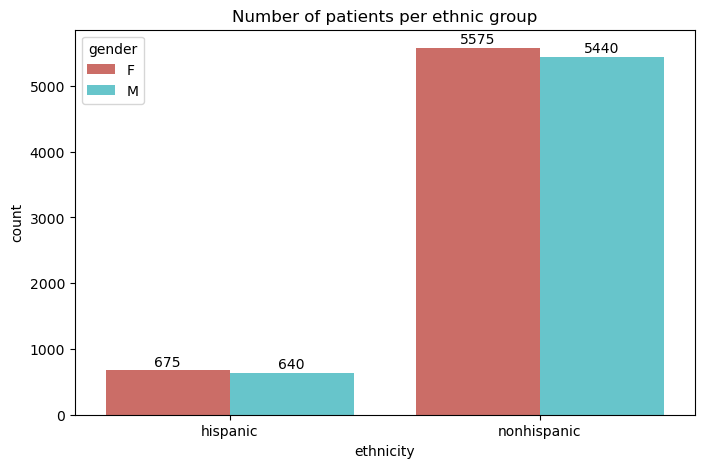

In [91]:
fig = plt.figure(figsize=(8, 5)) #obs_x[obs_x['units'] == 'other'].loc[:, 'value'].unique()

ax = sns.barplot(
    (full[['patient','gender', 'ethnicity']]
        .drop_duplicates(subset=['patient'])
        .drop(columns='patient')
        .value_counts(['gender', 'ethnicity'])
        .reset_index(name='count') # resetear indicer y agregar el conteo como columna 
    ),
    y='count',
    x='ethnicity',
    hue='gender',
    palette='hls'
   );
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1);
ax.set_title('Number of patients per ethnic group');

**Definicion de grupo y justificacion: A partir de esto defino el grupo con el que respondere el resto de preguntas clinicas: pacientes hispanicos, tanto hombres como mujeres, con la idea de buscar dimorfismos sexuales**

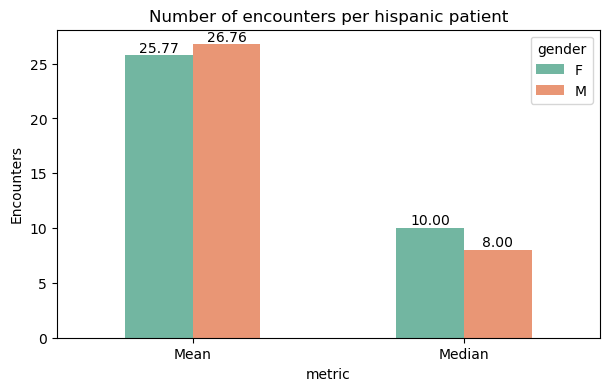

In [92]:
xx = (full[(full['ethnicity']=='hispanic')]  # filtar por grupo etnico
    .loc[:, ['patient', 'encounter', 'gender']]  # recuperar columnas de interes
    .drop_duplicates(subset=['encounter']) # me deshaho de encuentros duplicados porque hay una entry para cada observacion hecha en ese encuentro
    .value_counts(['patient', 'gender'])   # contar valores para paciente y genero
    .reset_index(name='count')     # reiniciar indice y agregar conteo como columna
    .drop(columns='patient')       # soltar columna innecesaria
    .groupby('gender', observed=True)['count']    # agrupar por genero, recuperar conteo
    .agg(Mean='mean', Median='median')            # calcular media y mediana
    .reset_index()
    .melt(id_vars='gender', var_name='metric', value_name='value')  # reestructurar
     )
fig = plt.figure(figsize=(7,4))
ax = sns.barplot( # plotear
    data = xx,
    x = 'metric',
    y = 'value',
    hue = 'gender',
    palette = 'Set2',
    legend = True,
    width = 0.5
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=0.25)
ax.set_ylabel('Encounters')
ax.set_title('Number of encounters per hispanic patient');
del xx;

Para los codigos de observacion si tuve que investigar en internet, ya que el diccionario solo decia que es "Observation or Lab code from LOINC", pero no sabia que significa eso. Investigando un poco y si entendi bien, en este caso se trata de un codigo que sera unico para el resultado del test, prueba o procedimiento que se le haga al paciente durante el encuentro. En ese caso no debo colapsar duplicados de pacientes ni de encuentros, ya que en un mismo encuentro a un paciente se le pueden realizar varias observaciones que resulten cada una en un codigo distinto. Quiere decir que debo mantener el dataset completo, ya que esta construido a partir de cada observacion.

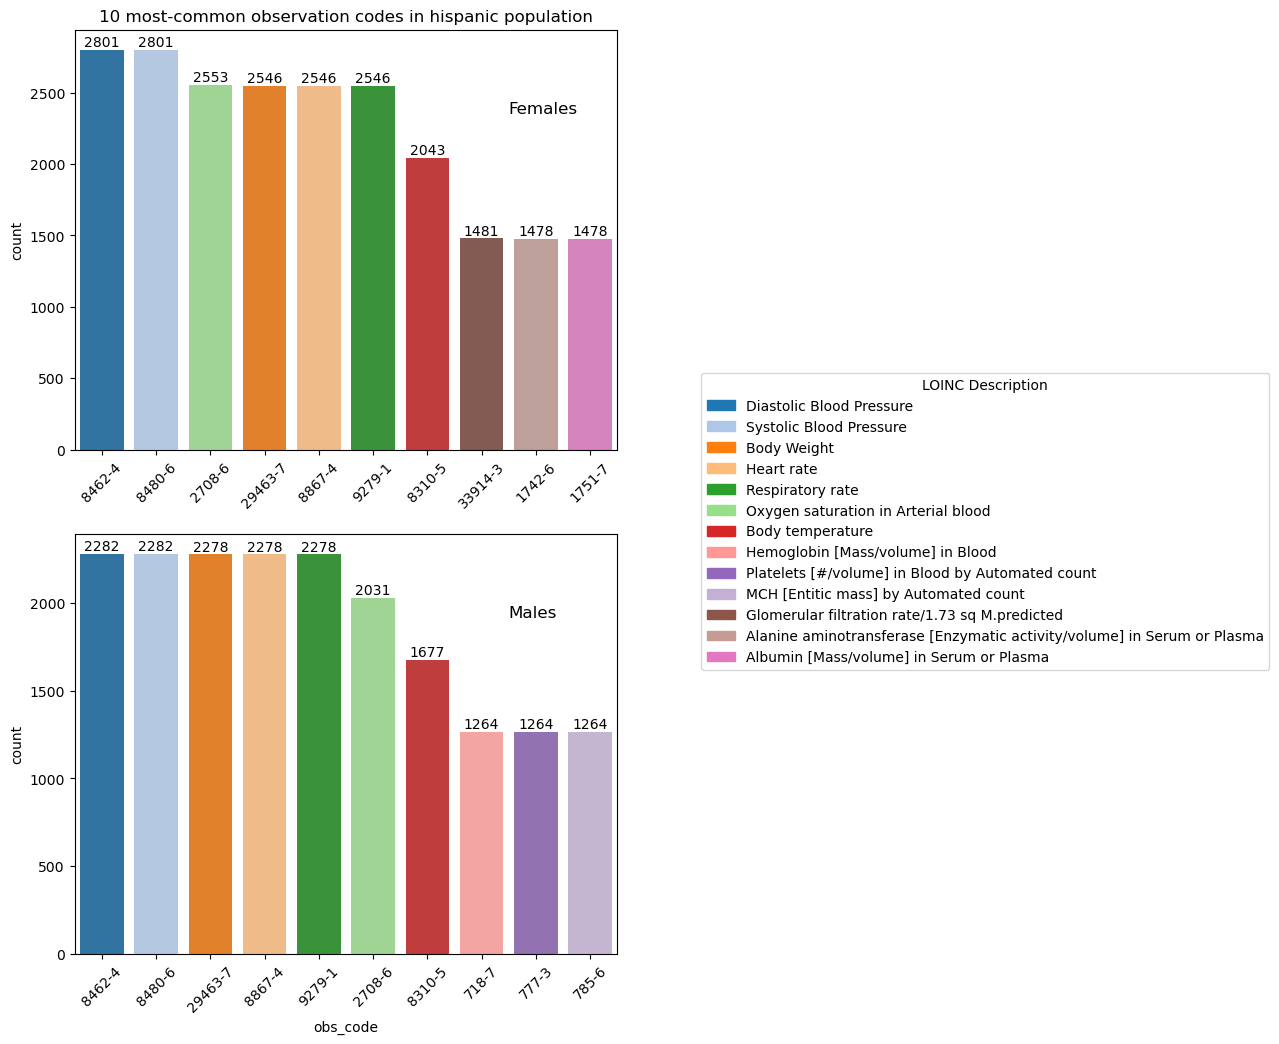

In [93]:
n = 10
cols = ['gender', 'obs_code', 'obs_desc']
data = (full[full['ethnicity'] == 'hispanic']
    .loc[:, cols]
    .dropna(subset=['obs_code']) # quitar observaciones sin codigo de ibservacion en caso de que llegara a haber
    .groupby(cols, observed=True) # agrupar 
    .value_counts()  # contar codigos observados por genero
    .reset_index(name='count')  # reiniciar inidce y agregar conteo como columna
    .sort_values(['gender','count'], ascending=False)   # acomodar de mayor a menor por conteo
    .groupby('gender', observed=True)   # agrupar por genero
    .head(n)    # recuperar n entradas en este caso top 10
    .reset_index(drop=True)
       )

data['obs_desc'] = data['obs_desc'].astype(str)
data['obs_code'] = data['obs_code'].astype(str)
shared = data['obs_desc'].unique().tolist() 
colors = dict(zip(shared, sns.color_palette('tab20', n_colors=len(shared))));
fig, axs = plt.subplots(2, 1, figsize=(7,12))#, sharey=True)

for i, gender in enumerate(('F', 'M')):
    ax = axs[i]
    sns.barplot(data = data[data['gender'] == gender],
                    x = 'obs_code',
                    y = 'count',
                    hue = 'obs_desc',
                    palette = colors,
                    ax = ax,
                    legend = False)
    
    ax.tick_params(axis='x', rotation=45)
    ax.text(0.8, 0.8, 'Females' if i==0 else 'Males', transform=ax.transAxes, fontsize=12)
    for container in ax.containers:
        ax.bar_label(container, padding=0.2);
    
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[desc]) for desc in shared]
fig.legend(
    handles=handles,
    labels=shared,
    title='LOINC Description',
    bbox_to_anchor=(1.01, 0.6), 
    loc='upper left',
    frameon=True
);
axs[0].set_xlabel('')
axs[0].set_title('10 most-common observation codes in hispanic population');
#ax.set_xticks(xx)
#ax.set_xticklabels(labels=data['obs_code'].to_list(), rotation=45);
del n, cols, data, colors, shared

**Para la ultima pregunta clinica, elegi trabajar con la variable "Hemoglobin [Mass/Volume] in Blood"**

In [94]:
(full
    [(full['ethnicity']=='hispanic') & (full['obs_code']=='718-7') & (full['gender'] == 'M')]
)[['encounter', 'patient','date', 'num_val','units']].head(12).reset_index()

,index,encounter,patient,date,num_val,units
0,3396,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-10,13.4,g/dL
1,3446,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-11,13.2,g/dL
2,3487,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-12,11.8,g/dL
3,3537,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-13,11.7,g/dL
4,3578,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-14,12.2,g/dL
5,3628,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-15,13.3,g/dL
6,3669,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-16,11.5,g/dL
7,3719,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-17,11.8,g/dL
8,3760,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-18,11.3,g/dL
9,3810,dc2cb1fd-e8fc-47fe-837c-4272c928c790,5b61f0fa-a3c4-4e70-a322-ad85c47aca12,2020-03-19,11.5,g/dL


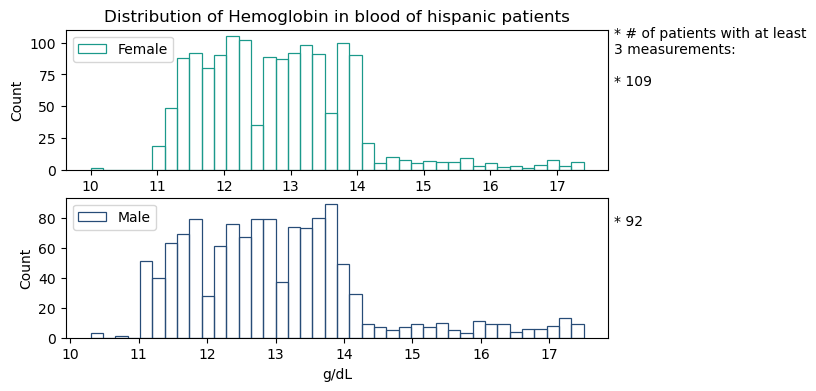

In [95]:
fig, axs = plt.subplots(2, 1, figsize=(7,4))
colors = ('#1B998B','#274C77')
data = (full
    [(full['ethnicity'] == 'hispanic') & (full['obs_code'] == '718-7')]
    [['patient', 'gender', 'num_val']]
    .dropna(subset=['num_val'])
       )
for i, gender in enumerate(('F','M')):
    ax = axs[i]
    sns.histplot(data[data['gender'] == gender]['num_val'],
                 ax=ax,
                 bins=40,
                 fill=False,
                 color=colors[i],
                 label='Female' if i==0 else 'Male',
                 legend=True)
    ax.legend(loc='upper left', frameon=True);
axs[0].set_title('Distribution of Hemoglobin in blood of hispanic patients')
axs[1].set_xlabel('g/dL');
data = (data
    .groupby(['patient', 'gender'], observed=True)
    .size()
    .loc[lambda s: s >= 3]              
    .reset_index(name='obs_count')
    .groupby('gender', observed=True)   
    .size()     
    .reset_index(name='patient_count')
       )
x = data['patient_count'].values
axs[0].text(1.01, 1.8, f'* # of patients with at least\n3 measurements:\n\n* {x[0]}', transform=ax.transAxes);
axs[0].text(1.01, 0.8, f'* {x[1]}', transform=ax.transAxes);

# 6. Formato ancho y valores implausibles

In [96]:
obs2.dtypes

date           datetime64[ns]
patient              category
encounter            category
obs_code             category
obs_desc             category
units                category
num_val               float32
non_num_val          category
dtype: object

In [97]:
(
    obs2
    .pivot_table(
        index = ['patient', 'encounter'],
        columns = 'obs_desc',
        values = 'num_val',
        observed = True
    )
).reset_index()

obs_desc,patient,encounter,ALT (Elevated),AST (Elevated),Alanine aminotransferase [Enzymatic activity/volume] in Serum or Plasma,Albumin,Albumin [Mass/volume] in Serum or Plasma,Alkaline Phosphatase,Alkaline phosphatase [Enzymatic activity/volume] in Serum or Plasma,American house dust mite IgE Ab in Serum,...,VR-12 Vitality (VT) score - oblique method,WBC Auto (Bld) [#/Vol],Walnut IgE Ab in Serum,Weight difference [Mass difference] --pre dialysis - post dialysis,Weight-for-length Per age and sex,Wheat IgE Ab in Serum,White Blood Cell (Elevated),White oak IgE Ab in Serum,pH of Arterial blood,pH of Urine by Test strip
0,0000b247-1def-417a-a783-41c8682be022,93c3da2d-9420-49fa-94e3-7140ab9aeba1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000b247-1def-417a-a783-41c8682be022,a5f3c5a7-fdf9-4bc5-94e2-4e93b11994cb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00049ee8-5953-4edd-a277-b9c1b1a7f16b,dab47020-5bd0-4ce6-ae5c-e4f1ebd04627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000769a6-23a7-426e-a264-cb0e509b2da2,247c24bc-258b-459c-a001-b911bd427f8d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00079a57-24a8-430f-b4f8-a1cf34f90060,2e72da06-9187-404d-85a4-fa5c0b68e86b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38867,ffdbbb1b-745e-4e38-ade2-a19d6e778fee,3f6293cf-f83b-4158-979a-cd5a5900bb8b,NaN,NaN,29.480000,NaN,4.9,NaN,77.080002,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38868,ffdbbb1b-745e-4e38-ade2-a19d6e778fee,7e95279b-3417-43b2-b6c8-c7d3a891eff7,NaN,NaN,40.400002,NaN,4.8,NaN,122.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38869,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,37d9921d-44e5-4113-97e0-6432b31ab032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38870,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,c680806e-34af-43ce-9cc6-47c05e2c8a2c,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**con esta primera aproximacion me puedo dar cuenta de que como filas estoy conservando pacientes repetidos pero encuentros unicos. Esto quiere decir que la reduccion de dimensiones ocurrio sobre los encuentros. Revisando la documentacion me doy cuenta que el comportamiento default es calculcar la media, indicando que encuentros con varias observaciones de la misma medida se promedian. Considerando que la pregunta a responder son valores atípicos me doy cuenta por que es importante mantener la fecha dentro del parametro index, para mantener estas columnas separadas.
Tambien, al investigar los rangos fisiologicos para la variable que eledi me di cuenta que cambia de acuerdo con la edad, asi que agregare ese dato para hacer una estimacion mas limpia**

In [98]:
obs2 = obs2.merge(
    pat2[['patient', 'birthdate', 'gender']],
    on='patient',
    how='left'
)

obs2['age_at_obs'] = (
    (obs2['date'] - obs2['birthdate']).dt.days / 365
).astype('float32')

obs2 = obs2.drop(columns=['birthdate'])

In [99]:
long_obs = (
    obs2
    .pivot_table(
        index = ['patient', 'date', 'age_at_obs', 'gender'],
        columns = 'obs_desc',
        values = 'num_val',
        observed = True,
    )
).reset_index()
long_obs

obs_desc,patient,date,age_at_obs,gender,ALT (Elevated),AST (Elevated),Alanine aminotransferase [Enzymatic activity/volume] in Serum or Plasma,Albumin,Albumin [Mass/volume] in Serum or Plasma,Alkaline Phosphatase,...,VR-12 Vitality (VT) score - oblique method,WBC Auto (Bld) [#/Vol],Walnut IgE Ab in Serum,Weight difference [Mass difference] --pre dialysis - post dialysis,Weight-for-length Per age and sex,Wheat IgE Ab in Serum,White Blood Cell (Elevated),White oak IgE Ab in Serum,pH of Arterial blood,pH of Urine by Test strip
0,0000b247-1def-417a-a783-41c8682be022,2019-12-03,12.008219,F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000b247-1def-417a-a783-41c8682be022,2019-12-23,12.063014,F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0000b247-1def-417a-a783-41c8682be022,2020-02-18,12.219178,F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00049ee8-5953-4edd-a277-b9c1b1a7f16b,2019-11-20,35.021919,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00049ee8-5953-4edd-a277-b9c1b1a7f16b,2020-03-08,35.320549,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73180,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,2020-01-10,50.032875,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73181,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,2019-01-10,49.032875,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73182,ffea1d41-7562-499d-af1b-284ac72a7c3c,2020-03-12,44.975342,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73183,ffea1d41-7562-499d-af1b-284ac72a7c3c,2020-04-02,45.032875,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rangos fisiologicos para hemoglobina en sangre de adultos:
Hombre -> 14-18 g/dL
Mujer -> 12-16 g/dL

Recuperado de: Billett HH. Hemoglobin and Hematocrit. In: Walker HK, Hall WD, Hurst JW, editors. Clinical Methods: The History, Physical, and Laboratory Examinations. 3rd edition. Boston: Butterworths; 1990. Chapter 151. Available from: https://www.ncbi.nlm.nih.gov/books/NBK259/

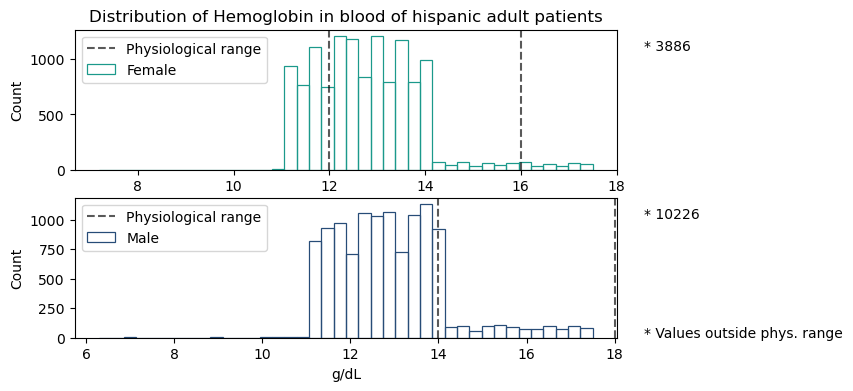

In [100]:
fisio_hemo = {'M': (14, 18),
              'F': (12, 16)}
h = 'Hemoglobin [Mass/volume] in Blood'

fig, axs = plt.subplots(2, 1, figsize=(7,4))
colors = ('#1B998B','#274C77')
data = (long_obs
       [long_obs['age_at_obs'] >= 18.0][['gender', h]]   # solo adultos
        .dropna(subset=[h])     # quitar observaciones en las que no se hizo esa medicion en particular
       )
for i, gender in enumerate(('F','M')):
    ax = axs[i]
    vals = data[data['gender']==gender][h]
    lower = fisio_hemo[gender][0]
    upper = fisio_hemo[gender][1]
    sns.histplot(vals,
                 ax=ax,
                 bins=40,
                 fill=False,
                 color=colors[i],
                 label='Female' if i==0 else 'Male',
                 legend=True)
    ax.axvline(lower,
              color='k',
              alpha=0.65,
              ls='--')
    ax.axvline(upper,
              label='Physiological range',
              color='k',
              alpha=0.65,
              ls='--')
    ax.legend(loc='upper left', frameon=True);
    vals = len(vals[(vals<=lower) | (vals>=upper)]) # valores por debajo del limite inferior o por encima del superior
    ax.text(1.05,0.85,'* '+str(vals), transform=ax.transAxes)
    #ax.set_ylim((0,200));
axs[0].set_title('Distribution of Hemoglobin in blood of hispanic adult patients')
axs[1].set_xlabel('g/dL');
axs[0].text(1.05, 0, '* Values outside phys. range', transform=ax.transAxes);

De entrada es evidente como la gran mayoria de los pacientes masculinos caen por fuera del rango fisiologico de hemoglobina en sangre. Primero pense que pudo haber sido un error, asi que regrese a los datos originales para verificar que no haya sido un error al momento de convertir dtypes, unir datasets o algo por el estilo. Incluso los datos "crudos" y sin separar por etnicidad ni sexo muestran una distribucion parecida, asi que todo parece indicar que no se trata de un error en el codigo. 

**Revisando la literatura, encontre que ya hay reportes de como el COVID puede reducir los niveles de hemoglobina en la sangre [1]. Sin embargo, no pude encontrar que este efecto haya sido encontrado unicamente en poblacion masculina ni hispanica. Por lo tanto, esto podría representar una primera evidencia de un hallazgo interesante, así como una dimorfismo sexual en cuanto a los efectos del COVID en el cuerpo.**

[1]: Lechuga GC, Morel CM, De-Simone SG. Hematological alterations associated with long COVID-19. Front Physiol. 2023 Jul 24;14:1203472. doi: 10.3389/fphys.2023.1203472. PMID: 37565145; PMCID: PMC10411895.

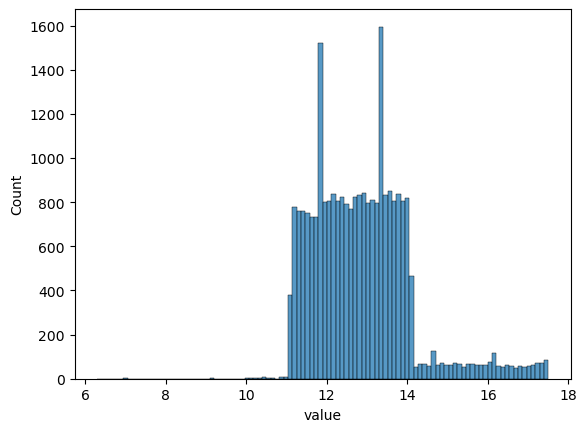

In [101]:
sns.histplot(obs[obs['code']=='718-7']['value'].astype('float32'));

# 7. Procesar por lotes lo que no cabe
Numero de pacientes: ~10k

Presupuesto: 100MB. 

Nota: empece con el presupuesto fijo en 200 MB, pero me di cuenta que el procesamiento que hago no lo supera. Como use una de las bases de datos prearmadas no puedo generar mas datos, asi que preferi bajar el presupuesto de memoria

In [102]:
%load_ext memory_profiler

In [103]:
def process_observations(file):
    # funcion para cargar desde 0 el archivo observations.csv y obtener conteos para cada codigo de observacion
    cols = ['PATIENT', 'ENCOUNTER', 'DESCRIPTION', 'CODE', 'UNITS', 'VALUE', 'DATE'] # no quiero type
    df = (pd.read_csv(file,
                      usecols = cols,
                      dtype = dict(zip(cols[:-1], (['category']*len(cols[:-2]))+['string'])), # -2 porque date va despues y value sera string
                      parse_dates = ['DATE']))
    df = (df
        .assign(units = df.UNITS.cat.add_categories(['other']).fillna('other').astype('category'),
                    num_val = pd.to_numeric(df['VALUE'], errors='coerce').astype('float32'),
                    non_num_val = df['VALUE'].where(df['UNITS'] == 'other', None).astype('category'))
        .drop(columns = ['VALUE'])
        .groupby('CODE', observed=True)['num_val']
        .agg(count='count', mean='mean')
        .reset_index()
        .sort_values('count', ascending=False)
         )
    return df

In [104]:
%%memit
test = process_observations('observations.csv')

peak memory: 1496.47 MiB, increment: 100.20 MiB


Aca puedo ver que el procesamiento, aunque es el ejemplo sencillo de conteo y media por codigo de observacion, resulta en un incremento de memoria de 135 MB. Nota: reporto el incremento porque si entendi bien lo que investigue sobre ese modulo (https://stackoverflow.com/questions/45318536/trying-to-understand-python-memory-profiler), el peak que devuelve incluye la memoria utlizada por el sistema, incluyendo otros procesos; mientras que increment indica la memoria utilizada por mi funcion, relativa a la memoria que ya se estaba utlizando como "linea base". Si eso es correcto, esta funcion para procesar las observaciones consume 135 MB, superando mi presupuesto de 100 MB. Si efectivamente estuviera limitado a usar unicamente 100 MB, tendria que dividir mi dataset en 2 lotes y procesarlos de manera independiente para poder mantenerme por debajo del presupuesto.

# 8. Los mismos resultados en Polars y en PySpark

## Pandas

Primero reimplemento parte de mi codigo anterior para recuperar las respuestas a las preguntas clinicas pero sin generar las graficas, ya que no son estrictamente necesarias y solo me van a consumir memoria

In [106]:
# Metere todo a funciones para facilitar los calculos de memoria y tiempo
# 1. Pacientes por grupo etnico y sexo
def clinical_one(df):
    uno = (df[['patient','gender', 'ethnicity']]
            .drop_duplicates(subset=['patient'])
            .drop(columns='patient')
            .value_counts(['gender', 'ethnicity'])
            .reset_index(name='count'))
    return uno

In [107]:
uno = clinical_one(full)
uno

,gender,ethnicity,count
0,F,nonhispanic,5575
1,M,nonhispanic,5440
2,F,hispanic,675
3,M,hispanic,640


In [108]:
%%memit 
test = clinical_one(full)

peak memory: 1429.61 MiB, increment: 34.36 MiB


In [109]:
# 2. Numero medio y mediano de encuentros por paciente
# Nota: anteriormente habia definido trabajar unicamente con pacientes hispanicos, ahora trabajare con el dataset completo para que
# las estimaciones de memoria y tiempo reflejen operaciones mas costosas
def clinical_two(df):
    dos = (df
    .loc[:, ['patient', 'encounter', 'gender']]
    .drop_duplicates(subset=['encounter']) # me deshaho de encuentros duplicados porque hay una entry para cada observacion hecha en ese encuentro
    .value_counts(['patient', 'gender'])
    .reset_index(name='count')
    .drop(columns='patient')
    .groupby('gender', observed=True)['count']
    .agg(Mean='mean', Median='median')
    .reset_index()
    .melt(id_vars='gender', var_name='metric', value_name='value')
        )
    return dos

In [110]:
test = clinical_two(full)
print(test)

,gender,metric,value
0,F,Mean,24.382880
1,M,Mean,27.818257
2,F,Median,11.000000
3,M,Median,9.000000


In [111]:
%%memit
test = clinical_two(full)

peak memory: 1443.59 MiB, increment: 47.36 MiB


In [112]:
n = 10
def clinical_three(df, n):
    cols = ['gender', 'obs_code', 'obs_desc']
    tres = (df
        .loc[:, cols]
        .dropna(subset=['obs_code']) 
        .groupby(cols, observed=True) 
        .value_counts() 
        .reset_index(name='count')
        .sort_values(['gender','count'], ascending=False)
        .groupby('gender', observed=True)   
        .head(n)    
        .reset_index(drop=True)
           )
    return tres

In [113]:
test = clinical_three(full, n)
print(test)

,gender,obs_code,obs_desc,count
0,M,8462-4,Diastolic Blood Pressure,23692
1,M,8480-6,Systolic Blood Pressure,23692
2,M,29463-7,Body Weight,22420
3,M,8867-4,Heart rate,22420
4,M,9279-1,Respiratory rate,22420
5,M,2708-6,Oxygen saturation in Arterial blood,20350
6,M,8310-5,Body temperature,16623
7,M,33914-3,Glomerular filtration rate/1.73 sq M.predicted,12718
8,M,1742-6,Alanine aminotransferase [Enzymatic activity/v...,12704
9,M,1751-7,Albumin [Mass/volume] in Serum or Plasma,12704


In [114]:
%%memit
test = clinical_three(full, n)

peak memory: 1478.28 MiB, increment: 81.99 MiB


In [115]:
def clinical_four(df):
    _fig, axs = plt.subplots(2, 1, figsize=(7,4))
    colors = ('#1B998B','#274C77')
    cuatro = (
    df[df['obs_code'] == '718-7']
        [['patient', 'gender', 'num_val']]
    .dropna(subset=['num_val'])
    )
    for i, gender in enumerate(('F','M')):
        ax = axs[i]
        sns.histplot(cuatro[cuatro['gender'] == gender]['num_val'],
                     ax=ax,
                     bins=40,
                     fill=False,
                     color=colors[i],
                     label='Female' if i==0 else 'Male',
                     legend=True)
        ax.legend(loc='upper left', frameon=True);
    axs[0].set_title('Distribution of Hemoglobin in blood of patients')
    axs[1].set_xlabel('g/dL');
    cuatro = (cuatro
        .groupby(['patient', 'gender'], observed=True)
        .size()
        .loc[lambda s: s >= 3]              
        .reset_index(name='obs_count')
        .groupby('gender', observed=True)   
        .size()     
        .reset_index(name='patient_count')
           )
    x = cuatro['patient_count'].values
    axs[0].text(1.01, 1.8, f'* # of patients with at least\n3 measurements:\n\n* {x[0]}', transform=ax.transAxes);
    axs[0].text(1.01, 0.8, f'* {x[1]}', transform=ax.transAxes);
    return cuatro

  gender  patient_count
0      F           1020
1      M            927
peak memory: 1399.11 MiB, increment: 2.78 MiB


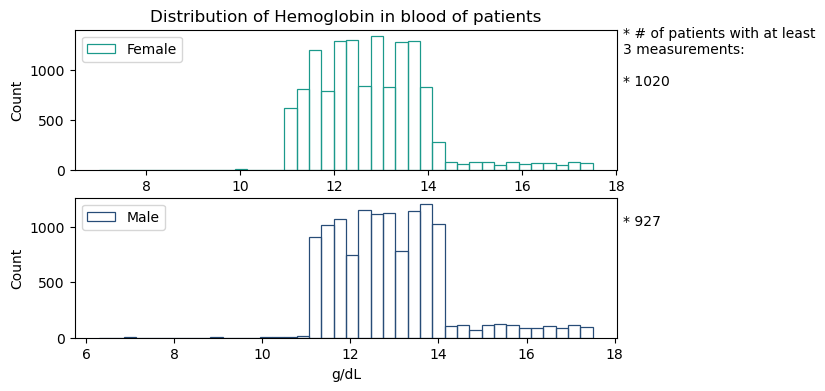

In [116]:
%%memit
test = clinical_four(full)
print(test)

In [118]:
%%timeit
# para contar el tiempo en una sola celda
test1 = clinical_one(full)
test2 = clinical_two(full)
test3 = clinical_three(full, n)
test4 = clinical_four(full)
plt.close();

1.42 s ± 25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Polars

In [119]:
# primero la lectura de archivos
# pacientes
pat_pl = (
    pl.read_csv('patients.csv',
        schema_overrides = {'Id': pl.Categorical,     # seleccionar dtypes
                            'BIRTHPLACE': pl.Categorical,
                            'RACE': pl.Categorical,
                            'ETHNICITY': pl.Categorical,
                            'GENDER': pl.Categorical,
                            'LAT': pl.Float32,
                            'LON': pl.Float32,
                            'HEALTHCARE_EXPENSES': pl.Float32,
                            'HEALTHCARE_COVERAGE': pl.Float32}
               )
    .select(pl.all().name.to_lowercase())  # igual convierto a minusculas para mantenerlo consistente con pandas
    .select(['id', 'birthdate', 'deathdate', 'ssn', 'race', 'ethnicity', 'gender', 'birthplace', 'lat', 'lon', 'healthcare_expenses', 'healthcare_coverage'])
    .with_columns([pl.col('birthdate').str.to_datetime(), # leer fechas
                   pl.col('deathdate').str.to_datetime(),
                   pl.col('ssn').str.replace_all('-', '').cast(pl.Int32)])
    .rename({'id': 'patient'})
)
pat_pl # se ve bien

patient,birthdate,deathdate,ssn,race,ethnicity,gender,birthplace,lat,lon,healthcare_expenses,healthcare_coverage
cat,datetime[μs],datetime[μs],i32,cat,cat,cat,cat,f32,f32,f32,f32
"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…",2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
"""067318a4-db8f-447f-8b6e-f2f61e…",2016-08-01 00:00:00,null,999155895,"""white""","""nonhispanic""","""F""","""Boston Massachusetts US""",42.177372,-71.281357,89893.398438,1845.719971
"""ae9efba3-ddc4-43f9-a781-f72019…",1992-06-30 00:00:00,null,999273385,"""white""","""nonhispanic""","""M""","""Springfield Massachusetts US""",42.181641,-72.608841,577445.875,3528.840088
"""199c586f-af16-4091-9998-ee4cfc…",2004-01-09 00:00:00,null,999732461,"""white""","""nonhispanic""","""F""","""Worcester Massachusetts US""",42.075291,-70.757034,336701.71875,2705.639893
"""353016ea-a0ff-4154-85bb-1cf8b6…",1996-11-15 00:00:00,null,999607372,"""white""","""nonhispanic""","""M""","""Patras Achaea GR""",42.352436,-71.02861,484076.34375,3043.040039
…,…,…,…,…,…,…,…,…,…,…,…
"""eec72396-d10e-4b8e-8fb6-25fc1e…",1962-08-17 00:00:00,null,999525112,"""asian""","""nonhispanic""","""F""","""Delhi Delhi IN""",42.294174,-71.259361,1.3323e6,7157.899902
"""3daf2b90-c439-469f-bb44-fb6109…",1918-10-20 00:00:00,1999-11-01 00:00:00,999251153,"""white""","""nonhispanic""","""F""","""New Bedford Massachusetts US""",42.372662,-71.209053,1.5572e6,27214.480469
"""cb03d88e-7f08-46a1-be78-70d9fe…",1918-10-20 00:00:00,2009-08-07 00:00:00,999417538,"""white""","""nonhispanic""","""F""","""Marshfield Massachusetts US""",42.396187,-71.217926,1.3479e6,26001.410156


In [120]:
# encuentros
enc_pl = (pl.read_csv('encounters.csv',
                   schema_overrides = {
                       'Id': pl.Categorical,
                       'PATIENT': pl.Categorical,
                       'ORGANIZATION': pl.Categorical,
                       'PROVIDER': pl.Categorical,
                       'PAYER': pl.Categorical,
                       'ENCOUNTERCLASS': pl.Categorical,
                       'CODE': pl.Categorical,
                       'DESCRIPTION': pl.Categorical,
                       'BASE_ENCOUNTER_COST': pl.Float32,
                       'TOTAL_CLAIM_COST': pl.Float32,
                       'PAYER_COVERAGE': pl.Float32,
                       'REASONCODE': pl.Float64,
                       'REASONDESCRIPTION': pl.Categorical})
    .select(pl.all().name.to_lowercase())
    .with_columns([pl.col('start').str.to_datetime(time_zone='UTC'),
                   pl.col('stop').str.to_datetime(time_zone='UTC')])
    .rename({'id': 'encounter',
             'description': 'enc_desc',
             'code': 'enc_code'})
)
enc_pl

encounter,start,stop,patient,organization,provider,payer,encounterclass,enc_code,enc_desc,base_encounter_cost,total_claim_cost,payer_coverage,reasoncode,reasondescription
cat,"datetime[μs, UTC]","datetime[μs, UTC]",cat,cat,cat,cat,cat,cat,cat,f32,f32,f32,f64,cat
"""d5ee30a9-362f-429e-a87a-ee38d9…",2019-02-16 01:02:32 UTC,2019-02-16 01:17:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""5103c940-0c08-392f-95cd-446e0c…","""e2c226c2-3e1e-3d0b-b997-ce9544…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""outpatient""","""185345009""","""Encounter for symptom""",129.160004,129.160004,69.160004,6.5363002e7,"""Otitis media"""
"""6a74fdef-2287-44bf-b9e7-180123…",2019-08-02 01:02:32 UTC,2019-08-02 01:32:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null
"""8bca6d8a-ab80-4cbf-8abb-466542…",2019-10-31 01:02:32 UTC,2019-10-31 01:17:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""5103c940-0c08-392f-95cd-446e0c…","""e2c226c2-3e1e-3d0b-b997-ce9544…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""outpatient""","""185345009""","""Encounter for symptom""",129.160004,129.160004,69.160004,6.5363002e7,"""Otitis media"""
"""821e57ac-9304-46a9-9f9b-83daf6…",2020-01-31 01:02:32 UTC,2020-01-31 01:17:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null
"""681c380b-3c84-4c55-80a6-db3d9e…",2020-03-02 01:02:32 UTC,2020-03-02 01:58:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""fd328395-ab1d-35c6-a2d0-d05a9a…","""9c875a09-93e0-39aa-9260-ad264b…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""ambulatory""","""185345009""","""Encounter for symptom (procedu…",129.160004,129.160004,69.160004,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""9af81365-e947-43b6-b4af-b94efb…",2020-05-19 06:03:58 UTC,2020-05-19 08:18:58 UTC,"""2712205f-755e-4897-acb3-926895…","""d5117822-5756-389d-9547-891a37…","""5ed53ed3-568e-3f70-9797-49ebdc…","""7caa7254-5050-3b5e-9eae-bd5ea3…","""ambulatory""","""185347001""","""Encounter for problem (procedu…",129.160004,129.160004,89.160004,null,null
"""823b575f-79ce-4946-917a-f7989c…",2020-05-26 06:03:58 UTC,2020-05-26 06:18:58 UTC,"""2712205f-755e-4897-acb3-926895…","""b60f8daf-0362-3c28-9b54-216e7f…","""23869b55-8805-3f41-8484-3d5c31…","""7caa7254-5050-3b5e-9eae-bd5ea3…","""urgentcare""","""702927004""","""Urgent care clinic (procedure)""",129.160004,129.160004,0.0,null,null
"""d4e1c9e6-2b5e-43a5-9fad-cef200…",2020-05-22 06:03:58 UTC,2020-05-22 09:18:58 UTC,"""2712205f-755e-4897-acb3-926895…","""d5117822-5756-389d-9547-891a37…","""5ed53ed3-568e-3f70-9797-49ebdc…","""7caa7254-5050-3b5e-9eae-bd5ea3…","""ambulatory""","""185347001""","""Encounter for problem (procedu…",129.160004,129.160004,89.160004,null,null


In [121]:
# observaciones
obs_pl = (pl.read_csv('observations.csv',
                   schema_overrides = {
                       'PATIENT': pl.Categorical,
                       'ENCOUNTER': pl.Categorical,
                       'CODE': pl.Categorical,
                       'DESCRIPTION': pl.Categorical})
    .select(pl.all().name.to_lowercase())
    .with_columns([pl.col('date').str.to_datetime(),
                   pl.col('units').fill_null('other').cast(pl.Categorical),
                   pl.col('value').cast(pl.Float32, strict=False).alias('num_val'),
                   pl.when(pl.col('units') == 'other')
                       .then(pl.col('value'))
                       .otherwise(None)
                       .cast(pl.Categorical)
                       .alias('non_num_val')])
    .drop(['type', 'value'])
    .rename({'description': 'obs_desc',
             'code': 'obs_code'})
)
obs_pl

date,patient,encounter,obs_code,obs_desc,units,num_val,non_num_val
datetime[μs],cat,cat,cat,cat,cat,f32,cat
2019-08-01 00:00:00,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""6a74fdef-2287-44bf-b9e7-180123…","""8302-2""","""Body Height""","""cm""",82.699997,null
2019-08-01 00:00:00,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""6a74fdef-2287-44bf-b9e7-180123…","""72514-3""","""Pain severity - 0-10 verbal nu…","""{score}""",2.0,null
2019-08-01 00:00:00,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""6a74fdef-2287-44bf-b9e7-180123…","""29463-7""","""Body Weight""","""kg""",12.6,null
2019-08-01 00:00:00,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""6a74fdef-2287-44bf-b9e7-180123…","""77606-2""","""Weight-for-length Per age and …","""%""",86.099998,null
2019-08-01 00:00:00,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""6a74fdef-2287-44bf-b9e7-180123…","""9843-4""","""Head Occipital-frontal circumf…","""cm""",46.900002,null
…,…,…,…,…,…,…,…
2020-02-11 00:00:00,"""2712205f-755e-4897-acb3-926895…",null,"""QALY""","""QALY""","""a""",59.5,null
2019-02-11 00:00:00,"""2712205f-755e-4897-acb3-926895…",null,"""DALY""","""DALY""","""a""",18.200001,null
2020-02-11 00:00:00,"""2712205f-755e-4897-acb3-926895…",null,"""DALY""","""DALY""","""a""",18.5,null


In [122]:
full_pl = (enc_pl
    .join(obs_pl, on=['patient', 'encounter'], how='left')
    .join(pat_pl, on='patient', how='left')
)
full_pl # tiene la misma forma que el de pandas, parece que todo bien, cualquier problema me dare cuenta durante las preguntas clinicas

encounter,start,stop,patient,organization,provider,payer,encounterclass,enc_code,enc_desc,base_encounter_cost,total_claim_cost,payer_coverage,reasoncode,reasondescription,date,obs_code,obs_desc,units,num_val,non_num_val,birthdate,deathdate,ssn,race,ethnicity,gender,birthplace,lat,lon,healthcare_expenses,healthcare_coverage
cat,"datetime[μs, UTC]","datetime[μs, UTC]",cat,cat,cat,cat,cat,cat,cat,f32,f32,f32,f64,cat,datetime[μs],cat,cat,cat,f32,cat,datetime[μs],datetime[μs],i32,cat,cat,cat,cat,f32,f32,f32,f32
"""d5ee30a9-362f-429e-a87a-ee38d9…",2019-02-16 01:02:32 UTC,2019-02-16 01:17:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""5103c940-0c08-392f-95cd-446e0c…","""e2c226c2-3e1e-3d0b-b997-ce9544…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""outpatient""","""185345009""","""Encounter for symptom""",129.160004,129.160004,69.160004,6.5363002e7,"""Otitis media""",null,null,null,null,null,null,2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
"""6a74fdef-2287-44bf-b9e7-180123…",2019-08-02 01:02:32 UTC,2019-08-02 01:32:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null,2019-08-01 00:00:00,"""8302-2""","""Body Height""","""cm""",82.699997,null,2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
"""6a74fdef-2287-44bf-b9e7-180123…",2019-08-02 01:02:32 UTC,2019-08-02 01:32:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null,2019-08-01 00:00:00,"""72514-3""","""Pain severity - 0-10 verbal nu…","""{score}""",2.0,null,2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
"""6a74fdef-2287-44bf-b9e7-180123…",2019-08-02 01:02:32 UTC,2019-08-02 01:32:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null,2019-08-01 00:00:00,"""29463-7""","""Body Weight""","""kg""",12.6,null,2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
"""6a74fdef-2287-44bf-b9e7-180123…",2019-08-02 01:02:32 UTC,2019-08-02 01:32:32 UTC,"""f0f3bc8d-ef38-49ce-a2bd-dfdda9…","""0b9f3f7c-8ab6-30a5-b3ae-4dc0e0…","""87c33fc5-3fd1-3c52-815a-b89a16…","""7c4411ce-02f1-39b5-b9ec-dfbea9…","""wellness""","""410620009""","""Well child visit (procedure)""",129.160004,129.160004,129.160004,null,null,2019-08-01 00:00:00,"""77606-2""","""Weight-for-length Per age and …","""%""",86.099998,null,2017-08-24 00:00:00,null,999686630,"""white""","""nonhispanic""","""M""","""Beverly Massachusetts US""",42.151962,-72.598961,8446.490234,1499.079956
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f69323ee-fc33-45ff-94ba-914acd…",2020-05-22 06:03:58 UTC,2020-05-22 06:18:58 UTC,"""2712205f-755e-4897-acb3-926895…","""d5117822-5756-389d-9547-891a37…","""5ed53ed3-568e-3f70-9797-49ebdc…","""7caa7254-5050-3b5e-9eae-bd5ea3…","""ambulatory""","""185347001""","""Encounter for problem (procedu…",129.160004,129.160004,89.160004,null,null,2020-05-22 00:00:00,"""5802-4""","""Nitrite [Presence] in Urine by…","""{nominal}""",null,null,1941-02-11 00:00:00,null,999574019,"""white""","""nonhispanic""","""M""","""Medford Massachusetts US""",41.721661,-70.587212,1.6892e6,790451.375
"""f69323ee-fc33-45ff-94ba-914acd…",20

In [123]:
# preguntas
def clinical_one_pola(df):
    uno = (df
        .unique(subset=['patient'])
        .group_by(['gender', 'ethnicity'])
        .len(name='count')
    )
    return uno

In [124]:
test = clinical_one_pola(full_pl)
print(test) # mismo resultado 

gender,ethnicity,count
cat,cat,u32
"""F""","""hispanic""",675
"""M""","""nonhispanic""",5440
"""M""","""hispanic""",640
"""F""","""nonhispanic""",5575


In [125]:
%%memit
test = clinical_one_pola(full_pl)

peak memory: 2125.94 MiB, increment: 0.00 MiB


In [126]:
def clinical_two_pola(df):
    dos = (df
        .unique(subset=['encounter'])
        .group_by(['patient', 'gender'])
        .len(name='count')
        .group_by('gender')
        .agg([pl.col('count').mean().alias('Mean'),
              pl.col('count').median().alias('Median')])
        .unpivot(on = ['Mean', 'Median'],
                 index = 'gender',
                 variable_name = 'metric',
                 value_name = 'value')
          )
    return dos

In [127]:
test = clinical_two_pola(full_pl)
print(test) # mismo resultado

gender,metric,value
cat,str,f64
"""M""","""Mean""",27.818257
"""F""","""Mean""",24.38288
"""M""","""Median""",9.0
"""F""","""Median""",11.0


In [128]:
%%memit
test = clinical_two_pola(full_pl)  # sin incremento???

peak memory: 2079.70 MiB, increment: 0.00 MiB


In [129]:
def clinical_three_pola(df, n):
    tres = (df
        .filter(pl.col('obs_code').is_not_null())
        .group_by(['gender', 'obs_code', 'obs_desc'])
        .len(name='count')
        .sort(['gender', 'count'], descending=[False, True])
        .group_by('gender')
        .head(n)
    )
    return tres

In [130]:
test = clinical_three_pola(full_pl, 10)
with pl.Config(tbl_rows=-1, tbl_cols=-1): # no me mostraba todas las filas
    print(test)

shape: (20, 4)
┌────────┬──────────┬─────────────────────────────────┬───────┐
│ gender ┆ obs_code ┆ obs_desc                        ┆ count │
│ ---    ┆ ---      ┆ ---                             ┆ ---   │
│ cat    ┆ cat      ┆ cat                             ┆ u32   │
╞════════╪══════════╪═════════════════════════════════╪═══════╡
│ M      ┆ 8462-4   ┆ Diastolic Blood Pressure        ┆ 23692 │
│ M      ┆ 8480-6   ┆ Systolic Blood Pressure         ┆ 23692 │
│ M      ┆ 29463-7  ┆ Body Weight                     ┆ 22420 │
│ M      ┆ 8867-4   ┆ Heart rate                      ┆ 22420 │
│ M      ┆ 9279-1   ┆ Respiratory rate                ┆ 22420 │
│ M      ┆ 2708-6   ┆ Oxygen saturation in Arterial … ┆ 20350 │
│ M      ┆ 8310-5   ┆ Body temperature                ┆ 16623 │
│ M      ┆ 33914-3  ┆ Glomerular filtration rate/1.7… ┆ 12718 │
│ M      ┆ 2885-2   ┆ Protein [Mass/volume] in Serum… ┆ 12704 │
│ M      ┆ 1920-8   ┆ Aspartate aminotransferase [En… ┆ 12704 │
│ F      ┆ 8462-4   ┆ Dia

In [131]:
%%memit
test = clinical_three_pola(full_pl, 10)

peak memory: 2569.95 MiB, increment: 19.88 MiB


aca me di cuenta de un par de diferencias: 
+ aqui en polars, en Females, aparece el codigo 787-2 MCV, con conteo 13556. En pandas no aparece ese, sino 785-6 MCH, tambien con conteo de 13556. Entonces no devuelven exactamente el mismo resultado, pero tampoco es incorrecto ya que el conteo es el mismo. 
+ lo mismo para pasa para Males, con los codigos 1975-2 y 6768-6 apareciendo en polars, mientras que pandas muestra 1742-6 y 1751-7 en su lugar. Todos tienen el mismo conteo de 12704, asi que no se trata de un error.
+ Lo mismo pasa con PySpark, que agrega el codigo 786-4 en Females, pero con el mismo conteo de 13556. Tambien muestra el 6768-6 en Males
+ Probablemente se debe a una diferencia entre el manejo interno del acomodo de los datos entre polars, pandas y pyspark, algo como que uno usa automoticamente orden alfabetico o numerico, mientras que el otro los va acomodando conforme los encuentra o algo parecido.

In [132]:
def clinical_four_pola(df):
    _fig, axs = plt.subplots(2, 1, figsize=(7, 4))
    colors = ('#1B998B', '#274C77')
    cuatro_data = (df
        .filter((pl.col('obs_code') == '718-7') & (pl.col('num_val').is_not_null()))
        .select(['patient', 'gender', 'num_val']))
    for i, gender in enumerate(('F', 'M')):
        ax = axs[i]
        sns.histplot(data = (cuatro_data
                             .filter(pl.col('gender') == gender)['num_val']
                             .to_numpy()),
                     ax=ax,
                     bins=40,
                     fill=False,
                     color=colors[i],
                     label='Female' if i == 0 else 'Male',
                     legend=True)
        ax.legend(loc='upper left', frameon=True)
    axs[0].set_title('Distribution of Hemoglobin in blood of patients')
    axs[1].set_xlabel('g/dL')
    cuatro = (cuatro_data
        .group_by(['patient', 'gender'])
        .len(name='obs_count')
        .filter(pl.col('obs_count') >= 3)
        .group_by('gender')
        .len(name='patient_count'))
    x = cuatro['patient_count'].to_list()
    axs[0].text(1.01, 0.5, f'* # of patients with at least\n3 measurements:\n\n* {x[0]}', transform=axs[0].transAxes)
    axs[0].text(1.01, -0.5, f'* {x[1]}', transform=axs[0].transAxes)

    return cuatro

shape: (2, 2)
┌────────┬───────────────┐
│ gender ┆ patient_count │
│ ---    ┆ ---           │
│ cat    ┆ u32           │
╞════════╪═══════════════╡
│ M      ┆ 927           │
│ F      ┆ 1020          │
└────────┴───────────────┘
peak memory: 2570.00 MiB, increment: 0.00 MiB


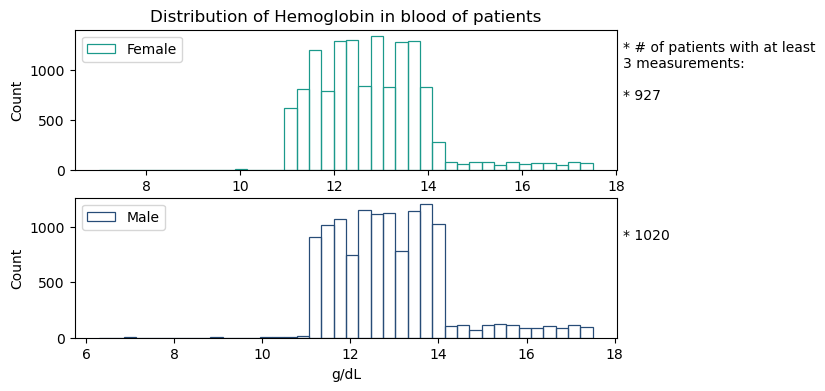

In [133]:
%%memit
test = clinical_four_pola(full_pl)
print(test) # mismo resultado

In [134]:
%%timeit
test1 = clinical_one_pola(full_pl)
test2 = clinical_two_pola(full_pl)
test3 = clinical_three_pola(full_pl, 10)
test4 = clinical_four_pola(full_pl)
plt.close()

720 ms ± 154 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [136]:
full.to_pickle('full.pkl')

## PySpark
Aca me tuve que pasar a colab porque nomas no pude iniciar sesion de spark aqui

| Herramienta | Lineas de codigo | Tiempo (s) | Memoria pico; incremento (MB) | Que costo mas |
|-------------|------------------|------------|-------------------------------|---------------|
| Pandas | 65 | 1.31 ± 121 ms | 867.41; 149.06 (%%memit) | La pregunta 4 (distribucion y pacientes con al menos 3 mediciones) consumio mas memoria |
| Polars | 63 | 0.456 ± 52.7 ms | 1516.76; 17.81 (%%memit) | La pregunta 3 (10 codigos mas frecuentes) consumio mas memoria, pero fue bastante menos que al hacerlo con pandas(15MB vs 82MB) |
| PySpark | 78 | 73 (individual, sumando lo que colab dice que tarda). 27.8 ± 637 ms (al correr las 4 en la misma celda, usando %%timeit)  | 2191.57; 0.05 (%%memit). 4.7(tracemalloc)  | La pregunta 2 (media y mediana de encuentros por paciente) consumio mas memoria |

**Notas:**
* En los tres casos, las sumas tanto de lineas de codigo como de tiempo consideran unicamente las funciones que responden las preguntas clinicas
* Como mencione antes, reporto tanto la memoria pico como el incremento que me devuelve %%memit, pero si entiendo bien, el dato util lo da el incremento, asi que en ese basare las conclusiones. Lo que hice fue que para cada una de las 4 funciones que hice para responder las preguntas clinicas, obtuve el pico y el incremento. Lo que reporto es el pico mas alto que vi entre las 4 y la suma de los 4 incrementos.
* Para replicar los resultados en PySpark tuve que pasarme a google colab porque nomas no pude lograr iniciar la sesion de spark aqui en el notebook. Al parecer habia un conflicto entre como instale pyarrow y pyspark y no lograba asignar un ambiente para la maquina virtual de java, se quedaba infinitamente intentando crear el ambiente. Estuve un par de horas intentando solucionarlo y me desespere y mejor me pase a colab, donde ya pude iniciar la sesion de spark en minutos.
* Tambien con PySpark tuve problemas para confiar en lo que me devolvia %%memit, ya que el pico salia bastante alto (~2000MB) pero el incremento de 0.05MB que reporto solo se dio al correr la segunda funcion, en todas las demas devolvio incremento de 0. En este caso tambien utilice tracemalloc para comparar y tambien salio muy bajo (~4 MB)

# 9. La recomendacion

Para este volumen de datos (~10k) pacientes, eligiria trabajar con pandas. El volumen es lo suficientemente bajo y el analisis lo suficientemente sencillo como para responder todas las preguntas sin necesidad de cambiar de motor. Tambien influye que anteriormente ya he trabajado con pandas, asi que la familiaridad con la libreria facilita la escritura de codigo. Por otro lado, Polars tambien lo considero buena opcion, ya que la sintaxis es muy parecida a la de pandas y ofrece  mejoras tanto en tiempo de procesamiento como en memoria utilizada. 

Si el volumen fuera, por decir algo, 10 veces mas grande, y los analisis fueran mas complicados, me quedaria con Polars, porque en ese caso se harian mas evidentes y saldrian a relucir los ahorros de memoria y tiempo. Tambien cabe mencionar que la sintaxis de polars es lo suficientemente parecida a la de pandas como para que pudiera migrar a esa libreria sin mayor problema.

Finalmente, PySpark no lo usaria a menos de que fuera completamente necesario debido al volumen de los datos. Este motor es mas complicado que los dos anteriores, comenzando desde la instalacion y las particularidades que tiene respecto a los recursos que utiliza en java. En algunas funciones especificas tiene argumentos y sintaxis parecidas a las de pandas y polars, pero en ciertos casos tienen una sintaxis distinta que toman mas tiempo dominar. Y eso con analisis sencillos; me imagino que con preguntas mas complicadas se requiere usar funciones mas avanzadas que no son tan intuibles de utlizar como las de pandas o polars. Tambien entiendo el punto de haber creado el ambiente de spark en local y que esto desaprovecha la verdadera fuerza de PySpark, asi como tambien es importante mencionar que la memoria utlizada si se ve bastante reducida en comparacion con pandas y polars. 

Habiendo considerado estos puntos, entiendo el valor y las implicaciones que utilizar cada motor introduce